# Local Volatility Modelling & Exotic Option Pricing

## Ce qu'on va construire

On va implémenter le **modèle de volatilité locale de Dupire (1994)** pour pricer des options exotiques (barrières).

**Le problème de départ** : Black-Scholes suppose que la volatilité σ est constante. Or sur le marché, quand on inverse les prix d'options observés pour extraire la vol implicite, on obtient une **surface** σ_imp(K, T) qui dépend du strike et de la maturité — c'est le **smile de volatilité**. BS est donc incohérent : il utilise σ = constante mais le marché lui-même dit que σ varie.

**La solution de Dupire** : remplacer σ = constante par σ = σ_loc(S, t), une fonction déterministe du spot et du temps, calibrée pour reproduire **exactement** tous les prix vanilles du marché. C'est le modèle le plus naturel au-delà de BS.

**Pourquoi c'est important pour les exotiques** : une option vanille ne dépend que de la distribution terminale de S_T. Plusieurs modèles (BS flat, vol locale, vol stochastique) peuvent donner la même distribution terminale. Mais une option barrière dépend de **toute la trajectoire** — et là, ces modèles divergent. Un BS flat peut se tromper de 10-20% sur une barrière. D'où la nécessité de Dupire.

## Plan du notebook

1. **Pricer Black-Scholes** — notre brique de base (rapide)
2. **Surface de vol implicite** — construction via SVI, le smile en détail
3. **Formule de Dupire** — extraction de la vol locale, le cœur du projet
4. **Monte Carlo sous vol locale** — simulation et pricing
5. **Options barrières** — pricing et comparaison LV vs BS flat
6. **Greeks** — sensibilités par bump-and-reprice
7. **Benchmark & visualisations** — résultats finaux

In [2]:
# =============================================================
# IMPORTS & CONFIGURATION
# =============================================================

import numpy as np                  # calcul numérique (arrays, maths)
from scipy.stats import norm        # loi normale : Φ(x) et φ(x) pour BS
from scipy.optimize import brentq   # recherche de racine pour la vol implicite
from scipy.interpolate import RectBivariateSpline  # interpolation 2D de la surface de vol
import matplotlib.pyplot as plt     # graphiques
from mpl_toolkits.mplot3d import Axes3D  # surface 3D

# Config graphiques : plus lisible que les défauts matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Seed pour la reproductibilité du Monte Carlo
# (tout le monde obtient les mêmes résultats avec le même seed)
RNG = np.random.default_rng(42)

print("Setup OK")

Setup OK


## 1. Pricer Black-Scholes

On connaît la formule, donc on ne va pas re-dériver. On code les briques dont on aura besoin pour la suite :

- `bs_d1d2` — calcule d1 et d2 (réutilisés partout : prix, delta, vega...)
- `bs_call_price` — prix du call : C = S·e^{-qT}·Φ(d1) - K·e^{-rT}·Φ(d2)
- `bs_put_price` — prix du put via parité call-put (on ne recode pas une 2e formule, la parité est toujours vraie quel que soit le modèle)
- `bs_vega` — ∂C/∂σ = S·e^{-qT}·√T·φ(d1). Toujours positif, c'est ce qui garantit que la vol implicite est unique et inversible. On en aura besoin pour Newton-Raphson plus tard.

**Pourquoi on commence par là ?** Parce que la vol implicite est le langage de tout le projet. Surface de vol, Dupire, pricing — tout passe par ce module.

In [3]:
# =============================================================
# PRICER BLACK-SCHOLES
# =============================================================

def bs_d1d2(S, K, T, r, q, sigma):
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    return d1, d2

def bs_call_price(S, K, T, r, q, sigma):
    d1, d2 = bs_d1d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put_price(S, K, T, r, q, sigma):
    return bs_call_price(S, K, T, r, q, sigma) - S * np.exp(-q * T) + K * np.exp(-r * T)

def bs_vega(S, K, T, r, q, sigma):
    d1, _ = bs_d1d2(S, K, T, r, q, sigma)
    return S * np.exp(-q * T) * np.sqrt(T) * norm.pdf(d1)

print("Pricer BS chargé")

Pricer BS chargé


### Test : parité call-put

On vérifie que le pricer marche sur un cas ATM (S=K=100, T=1Y, σ=20%). La parité call-put C - P = S·e^{-qT} - K·e^{-rT} doit être respectée à la précision machine (~10⁻¹⁶). Si ce test ne passe pas, rien d'autre ne marchera.

In [4]:
S0, K, T, r, q, sigma = 100, 100, 1.0, 0.05, 0.02, 0.20

C = bs_call_price(S0, K, T, r, q, sigma)
P = bs_put_price(S0, K, T, r, q, sigma)
parite = C - P - (S0 * np.exp(-q * T) - K * np.exp(-r * T))

print(f"Call ATM  = {C:.4f}")
print(f"Put ATM   = {P:.4f}")
print(f"Vega      = {bs_vega(S0, K, T, r, q, sigma):.4f}")
print(f"Parité call-put : erreur = {parite:.2e}  ({'OK' if abs(parite) < 1e-10 else 'PROBLÈME'})")

Call ATM  = 9.2270
Put ATM   = 6.3301
Vega      = 37.9012
Parité call-put : erreur = 0.00e+00  (OK)


Car parité Call Put pur resultat d'arbitrage pur et independant de BS

### Inversion de la volatilité implicite

On a un prix de marché C_mkt pour une option (K, T). On veut trouver le σ tel que BS(σ) = C_mkt. C'est un problème de recherche de racine en 1D.

**Pourquoi ça marche ?** La fonction σ → C_BS(σ) est strictement croissante (car le vega est toujours > 0) et varie entre deux bornes :
- σ → 0 : C → max(S·e^{-qT} - K·e^{-rT}, 0) — la valeur intrinsèque actualisée
- σ → +∞ : C → S·e^{-qT} — la valeur max du call (on ne peut pas recevoir plus que l'actif)

Donc pour tout prix de marché **entre ces deux bornes**, il existe un unique σ_imp. Si le prix de marché sort de cet intervalle, aucun σ ne peut matcher — c'est le signe d'un arbitrage (ou en pratique, de données sales).

**Quelle méthode utiliser ?**

On implémente **Brent** — c'est le standard en production. L'algorithme combine trois méthodes :
- **Bisection** : coupe l'intervalle en deux à chaque itération. Lent (convergence linéaire) mais ne rate jamais.
- **Sécante** : utilise les deux derniers points pour extrapoler. Plus rapide mais peut sortir de l'intervalle.
- **Interpolation quadratique** : encore plus rapide quand la fonction est bien lisse.

À chaque itération, Brent choisit la méthode la plus rapide qui reste dans l'intervalle. Si aucune ne convient, il fait une bisection. Résultat : convergence **garantie** en 10-15 itérations.

L'alternative serait **Newton-Raphson** (on divise par le vega à chaque itération), c'est plus rapide (convergence quadratique) mais ça peut diverger quand le vega est quasi nul (options très OTM). Pour la robustesse, on reste sur Brent.

    On veut trouver σ tel que BS(σ) = market_price.
    On utilise Brent sur l'intervalle [0.1%, 1000%] avec une tolérance de 1e-12.
    Si aucune racine n'existe, on retourne NaN.

In [5]:
# =============================================================
# INVERSION DE LA VOL IMPLICITE — Méthode de Brent
# =============================================================

def implied_vol(market_price, S, K, T, r, q, option_type='call'):

    price_func = bs_call_price if option_type == 'call' else bs_put_price

    def objective(sigma):
        return price_func(S, K, T, r, q, sigma) - market_price

    try:
        return brentq(objective, 0.001, 10.0, xtol=1e-12)
    except ValueError:
        return np.nan

print("implied_vol OK")

implied_vol OK


### Test : roundtrip prix → vol → prix

On part d'un σ connu (20%), on calcule le prix BS, puis on inverse ce prix pour retrouver σ. On doit retomber sur 20% à la précision machine. C'est le test de base pour valider que l'inversion fonctionne, si le roundtrip échoue, toute la construction de la surface de vol sera fausse.

In [6]:
# Roundtrip : σ connu → prix → inversion → on doit retrouver σ
sigma_vrai = 0.20
prix = bs_call_price(S0, K, T, r, q, sigma_vrai)
sigma_retrouve = implied_vol(prix, S0, K, T, r, q)

print(f"σ de départ  = {sigma_vrai:.10f}")
print(f"Prix BS      = {prix:.6f}")
print(f"σ retrouvé   = {sigma_retrouve:.10f}")
print(f"Erreur       = {abs(sigma_retrouve - sigma_vrai):.2e}")

σ de départ  = 0.2000000000
Prix BS      = 9.227006
σ retrouvé   = 0.2000000000
Erreur       = 2.78e-17


## 2. Surface de volatilité implicite

On entre dans le vif du sujet. Sur le marché, quand on inverse les prix d'options pour différents strikes et maturités, on n'obtient **pas** un σ constant. On obtient une surface σ_imp(K, T) qui varie: c'est le **smile de volatilité**.

Avant de coder, on va d'abord **visualiser** ce phénomène pour bien comprendre ce qu'on modélise.

On va générer notre surface avec la paramétrisation **SVI** (Stochastic Volatility Inspired) de Gatheral (2004). C'est un modèle à 5 paramètres qui capture la forme du smile de manière réaliste et sans arbitrage. les données synthétiques sont propres, contrôlables, et disponibles sans connexion internet.

### La paramétrisation SVI

SVI modélise la **variance totale** w(k) = σ²_imp · T en fonction du log-forward-moneyness k = ln(K/F), où F = S·e^{(r-q)T} est le prix forward.

La formule :

$$w(k) = a + b\left[\rho(k - m) + \sqrt{(k-m)^2 + \sigma^2}\right]$$

Pourquoi la variance totale et pas la vol directement ? Parce que w est l'objet naturel : sa convexité en k est directement liée au non-arbitrage papillon, et elle est additive en temps sous certaines conditions. Travailler en vol directement masque ces propriétés.

Les 5 paramètres contrôlent chacun un aspect géométrique du smile :

| Paramètre | Rôle | Valeur typique equity |
|-----------|------|----------------------|
| **a** | Niveau global de variance (translation verticale) | > 0, croît avec T |
| **b** | Pente des ailes — plus b est grand, plus le smile est raide | 0.05 à 0.20 |
| **ρ** | Asymétrie du smile — ρ < 0 donne un skew négatif (typique equity) | -0.4 à -0.1 |
| **m** | Translation horizontale du minimum du smile | ≈ 0 |
| **σ_svi** | Courbure au sommet — arrondit le minimum du smile | 0.05 à 0.25 |

Le nom "Stochastic Volatility Inspired" vient du fait que cette forme est l'asymptotique exacte du modèle de Heston quand T → ∞. Ce n'est pas un fit ad hoc — la forme est motivée par la physique des modèles de vol stochastique.

In [7]:
# =============================================================
# PARAMÉTRISATION SVI
# =============================================================

def svi_total_variance(k, a, b, rho, m, sigma_svi):

    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma_svi**2))

def svi_implied_vol(k, T, a, b, rho, m, sigma_svi):
    """
    On déduit la vol implicite de la variance totale : σ_imp = √(w/T)
    On clamp w ≥ 0 pour éviter des racines de nombres négatifs.
    """
    w = svi_total_variance(k, a, b, rho, m, sigma_svi)
    return np.sqrt(np.maximum(w / T, 1e-8))

print("SVI OK")

SVI OK


### Paramètres SVI par maturité

On définit un jeu de paramètres réalistes type equity (Eurostoxx / S&P 500) pour 5 maturités de 1 mois à 2 ans. Ce qu'on observe dans les paramètres :

- **ρ** se rapproche de 0 quand T augmente → le skew est plus prononcé à court terme et s'aplatit avec le temps
- **b** augmente avec T → les ailes du smile deviennent plus raides à long terme
- **σ_svi** augmente avec T → le smile est plus arrondi à long terme
- **a** augmente avec T → la variance ATM croît avec le temps (logique : plus on attend, plus l'incertitude est grande)

On va tracer le smile pour chaque maturité pour visualiser ces effets.

In [8]:
# =============================================================
# PARAMÈTRES SVI — Données synthétiques réalistes
# =============================================================

S0 = 100
r = 0.03
q = 0.02

svi_params = {
    '1M':  {'a': 0.004, 'b': 0.08, 'rho': -0.40, 'm': 0.0, 'sigma_svi': 0.10},
    '3M':  {'a': 0.010, 'b': 0.10, 'rho': -0.35, 'm': 0.0, 'sigma_svi': 0.12},
    '6M':  {'a': 0.018, 'b': 0.12, 'rho': -0.30, 'm': 0.0, 'sigma_svi': 0.15},
    '1Y':  {'a': 0.030, 'b': 0.14, 'rho': -0.25, 'm': 0.0, 'sigma_svi': 0.18},
    '2Y':  {'a': 0.050, 'b': 0.15, 'rho': -0.20, 'm': 0.0, 'sigma_svi': 0.20},
}

maturities_days = {'1M': 30, '3M': 90, '6M': 180, '1Y': 365, '2Y': 730}
strikes = np.linspace(70, 130, 61)

print(f"Grille : {len(strikes)} strikes de {strikes[0]:.0f} à {strikes[-1]:.0f}")
print(f"Maturités : {list(maturities_days.keys())}")

Grille : 61 strikes de 70 à 130
Maturités : ['1M', '3M', '6M', '1Y', '2Y']


### Visualisation du smile par maturité

On trace σ_imp en fonction du moneyness (K/S₀ en %) pour chaque maturité. C'est le graphique le plus important pour comprendre le smile. On s'attend à voir :

1. **Un skew négatif** : la vol est plus haute à gauche (puts OTM) qu'à droite (calls OTM)
2. **Le smile s'aplatit avec T** : le skew 1M est beaucoup plus marqué que le skew 2Y
3. **Un vrai "smile"** : les deux ailes remontent, pas juste l'aile gauche — c'est le b qui fait ça

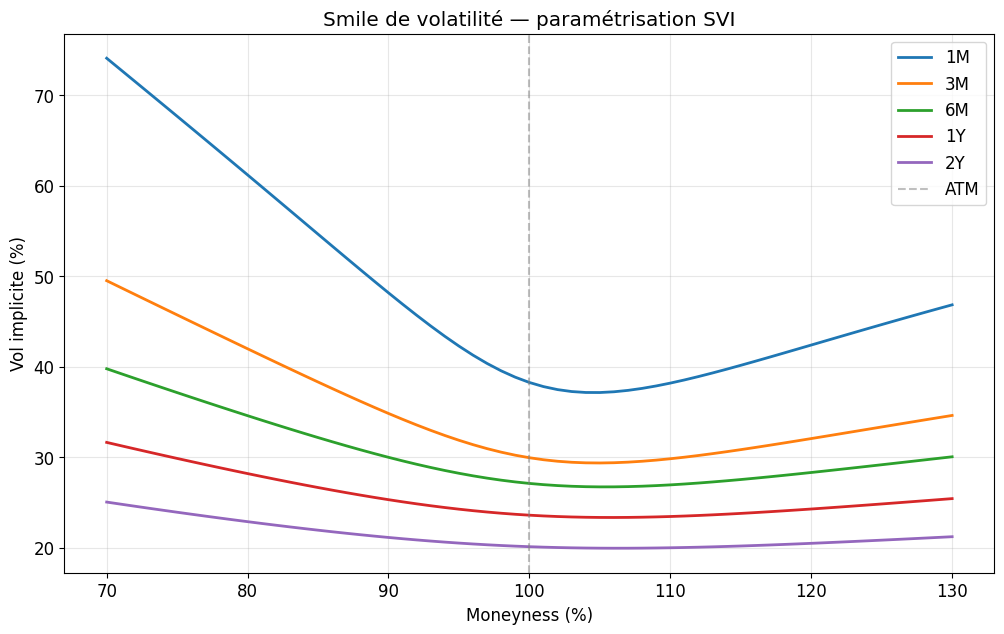

In [9]:
# =============================================================
# SMILE PAR MATURITÉ
# =============================================================

plt.figure(figsize=(12, 7))

for label, params in svi_params.items():
    T = maturities_days[label] / 365
    F = S0 * np.exp((r - q) * T)

    # Log-forward-moneyness pour chaque strike
    k = np.log(strikes / F)

    # Vol implicite SVI
    vols = svi_implied_vol(k, T, **params)

    moneyness = strikes / S0 * 100
    plt.plot(moneyness, vols * 100, linewidth=2, label=f'{label}')

plt.axvline(x=100, color='gray', linestyle='--', alpha=0.5, label='ATM')
plt.xlabel('Moneyness (%)')
plt.ylabel('Vol implicite (%)')
plt.title('Smile de volatilité — paramétrisation SVI')
plt.legend()
plt.show()

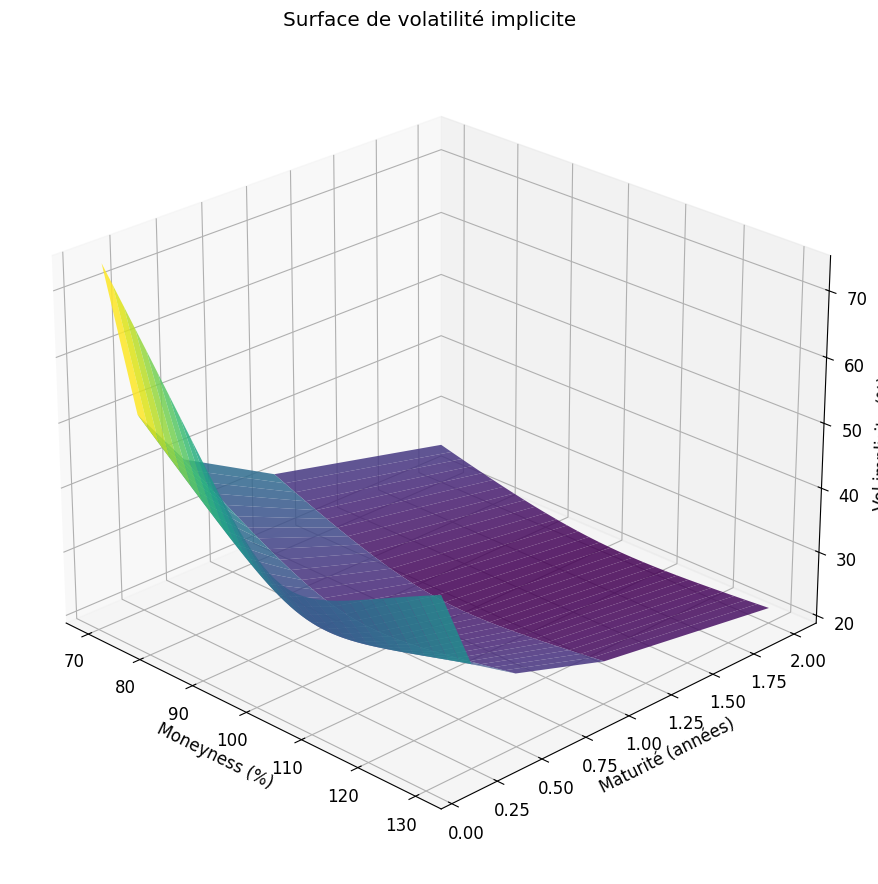

In [10]:
# =============================================================
# SURFACE DE VOL IMPLICITE EN 3D
# =============================================================

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

moneyness_grid = strikes / S0 * 100
labels = list(svi_params.keys())
mat_years = [maturities_days[l] / 365 for l in labels]

# On construit la matrice de vol (n_T × n_K)
vol_matrix = np.zeros((len(labels), len(strikes)))

for i, label in enumerate(labels):
    T = mat_years[i]
    F = S0 * np.exp((r - q) * T)
    k = np.log(strikes / F)
    vol_matrix[i, :] = svi_implied_vol(k, T, **svi_params[label])

K_grid, T_grid = np.meshgrid(moneyness_grid, mat_years)

ax.plot_surface(K_grid, T_grid, vol_matrix * 100,
                cmap='viridis', alpha=0.85, edgecolor='none')

ax.set_xlabel('Moneyness (%)')
ax.set_ylabel('Maturité (années)')
ax.set_zlabel('Vol implicite (%)')
ax.set_title('Surface de volatilité implicite')
ax.view_init(elev=25, azim=-45)
plt.tight_layout()
plt.show()

### Interprétation des graphiques

On travaille uniquement avec des calls. La vol implicite est obtenue en inversant le prix d'un call BS pour chaque couple (K, T). Voici ce qu'on lit sur nos graphiques.

**Graphique 2D — smile par maturité :**

- Pour une maturité fixée, la vol n'est **pas constante** en fonction du strike. C'est la preuve visuelle que BS à vol constante est insuffisant.
- Les strikes bas (70-85%) ont une vol beaucoup plus élevée que l'ATM (100%). Pour la courbe 1M (bleue) : ~74% à K=70 contre ~38% à l'ATM. Le marché considère qu'un mouvement de -30% en 1 mois est plus probable que ce que prédit la log-normale de BS.
- Les strikes hauts (115-130%) remontent aussi mais moins fort — le smile est asymétrique.
- Plus la maturité est longue, plus le smile est plat. À 2Y (violette), l'écart entre les ailes est d'environ 5 points de vol. À 1M (bleue), c'est ~35 points.

**Graphique 3D — surface complète :**

- C'est la même information vue dans son ensemble. Le pic jaune (coin haut-gauche) correspond aux strikes bas + courte maturité : c'est là que la vol est la plus élevée.
- La zone plate violette (droite, longues maturités) est la zone la plus calme.
- On voit clairement que cette surface n'est pas un plan horizontal — c'est ce qu'un BS à vol constante donnerait. Toute cette structure est ce que Dupire va capturer.

### Interpolation de la surface

On a une grille discrète de vols (5 maturités × 61 strikes). Mais Dupire aura besoin d'évaluer la vol — et donc le prix BS — à des points **quelconques** (K, T), y compris entre les nœuds de la grille. Il faut interpoler.

On utilise une **interpolation bicubique** (splines cubiques en 2D) via `RectBivariateSpline` de scipy. Pourquoi cubique ? Parce que Dupire a besoin de ∂C/∂T, ∂C/∂K et ∂²C/∂K² — donc la surface de prix doit être au moins C² (dérivée seconde continue). Les splines cubiques garantissent exactement ça.

On encapsule le tout dans une classe `VolSurface` qui expose deux méthodes :
- `implied_vol(K, T)` — vol implicite interpolée en un point quelconque
- `call_price(S, K, T, r, q)` — prix BS évalué avec la vol de la surface

In [11]:
# =============================================================
# CLASSE VOLSURFACE — Interpolation bicubique de la surface
# =============================================================

class VolSurface:
    """
    On stocke la grille discrète et on construit un interpolateur
    """

    def __init__(self, strikes, maturities, vol_matrix):
        self.strikes = np.asarray(strikes)
        self.maturities = np.asarray(maturities)
        self.vol_matrix = np.asarray(vol_matrix)

        # Interpolateur bicubique — kx=3, ky=3 = degré 3 (cubique) dans les deux directions
        # Attention à l'ordre des axes : x = maturités (lignes), y = strikes (colonnes)
        self._interp = RectBivariateSpline(
            self.maturities, self.strikes, self.vol_matrix,
            kx=3, ky=3
        )

    def implied_vol(self, K, T):
        """Vol implicite interpolée au point (K, T)."""
        # grid=False → évaluation ponctuelle, pas un produit cartésien
        # .item() → extrait le scalaire Python du array numpy retourné
        return self._interp(T, K, grid=False).item()

    def call_price(self, S, K, T, r, q):
        """Prix du call BS évalué avec la vol interpolée de la surface."""
        sigma = self.implied_vol(K, T)
        return bs_call_price(S, K, T, r, q, sigma)

# On construit la surface à partir de la matrice de vol qu'on a déjà calculée
mat_years = np.array([maturities_days[l] / 365 for l in svi_params.keys()])
surface = VolSurface(strikes, mat_years, vol_matrix)

print(f"VolSurface construite : {len(mat_years)} maturités × {len(strikes)} strikes")

VolSurface construite : 5 maturités × 61 strikes


### Test de l'interpolation

On vérifie deux choses :
1. **Aux nœuds de la grille** : l'interpolation doit redonner exactement les valeurs qu'on a mises. Si ce n'est pas le cas, l'interpolateur est mal construit.
2. **Entre les nœuds** : la vol interpolée doit être lisse (pas de saut), c'est-à-dire que la vol à K=99.5 doit être entre les vols à K=99 et K=100 (à peu de chose près).

In [12]:
# Test 1 : aux nœuds de la grille — on doit retomber sur la valeur exacte
T_test = mat_years[2]  # 6M
K_test = strikes[30]   # strike du milieu ≈ 100
vol_grille = vol_matrix[2, 30]
vol_interp = surface.implied_vol(K_test, T_test)

print("=== Test aux nœuds ===")
print(f"Vol dans la grille   = {vol_grille:.8f}")
print(f"Vol interpolée       = {vol_interp:.8f}")
print(f"Erreur               = {abs(vol_grille - vol_interp):.2e}")

# Test 2 : entre les nœuds — la vol doit être lisse
vol_99  = surface.implied_vol(99.0, T_test)
vol_995 = surface.implied_vol(99.5, T_test)
vol_100 = surface.implied_vol(100.0, T_test)

print("\n=== Test entre les nœuds ===")
print(f"Vol(K=99.0)  = {vol_99:.4%}")
print(f"Vol(K=99.5)  = {vol_995:.4%}")
print(f"Vol(K=100.0) = {vol_100:.4%}")
print(f"Lisse : {min(vol_99, vol_100) - 0.001 <= vol_995 <= max(vol_99, vol_100) + 0.001}")

=== Test aux nœuds ===
Vol dans la grille   = 0.27088691
Vol interpolée       = 0.27088691
Erreur               = 5.55e-17

=== Test entre les nœuds ===
Vol(K=99.0)  = 27.2535%
Vol(K=99.5)  = 27.1673%
Vol(K=100.0) = 27.0887%
Lisse : True


## 3. Formule de Dupire — Extraction de la volatilité locale

C'est le cœur du projet. On a une surface de vol implicite σ_imp(K, T) et on veut en déduire la **volatilité locale** σ_loc(K, T) — la fonction déterministe qui, injectée dans l'EDS

$$dS_t = (r - q) S_t \, dt + \sigma_{loc}(S_t, t) \, S_t \, dW_t$$

reproduit exactement tous les prix de calls observés.

La formule de Dupire (1994) donne directement σ_loc à partir de la surface de prix C(K, T) :

$$\sigma_{loc}^2(K, T) = \frac{\dfrac{\partial C}{\partial T} + (r-q) \, K \, \dfrac{\partial C}{\partial K} + q \, C}{\dfrac{1}{2} \, K^2 \, \dfrac{\partial^2 C}{\partial K^2}}$$

En pratique, on n'a pas les dérivées analytiques de C(K, T) — on les approxime par **différences finies** sur la surface interpolée. C'est là que la qualité de l'interpolation C² est cruciale : si la surface n'est pas lisse, les dérivées numériques sont instables et la vol locale explose.

### Différences finies pour Dupire

On a besoin de trois dérivées :

| Dérivée | Approximation (différences finies centrées) | Rôle dans Dupire |
|---------|---------------------------------------------|------------------|
| ∂C/∂K | [C(K+h) - C(K-h)] / 2h | Liée à la probabilité que S_T > K |
| ∂²C/∂K² | [C(K+h) - 2C(K) + C(K-h)] / h² | Liée à la densité risque-neutre (Breeden-Litzenberger) |
| ∂C/∂T | [C(T+δ) - C(T-δ)] / 2δ | La valeur temps de l'option |

Le choix des pas h et δ est un compromis :
- **Trop grand** → erreur de troncature (on approxime mal la dérivée)
- **Trop petit** → erreur d'arrondi (on soustrait deux nombres quasi égaux)

On prend h = 0.5 en strike et δ = 1/365 (un jour). C'est le standard pour ce type de calcul.

Le **dénominateur** ½K²·∂²C/∂K² doit être strictement positif — c'est une condition de non-arbitrage (convexité des prix en K). Si on tombe sur un dénominateur ≤ 0, c'est que la surface interpolée viole localement le non-arbitrage. Dans ce cas, on fait un fallback sur la vol implicite.

In [13]:
# =============================================================
# FORMULE DE DUPIRE — Volatilité locale par différences finies
# =============================================================

class DupireLocalVol:
    """
    On calcule σ_loc(K, T) à partir de la surface de prix C(K, T)
    en appliquant la formule de Dupire avec des différences finies centrées.
    """

    def __init__(self, vol_surface, S0, r, q):
        self.vol_surface = vol_surface
        self.S0 = S0
        self.r = r
        self.q = q

    def local_vol(self, K, T):
        dK = 0.5      # pas en strike
        dT = 1 / 365  # pas en temps (1 jour)
        S, r, q = self.S0, self.r, self.q

        # Prix central et prix bumpés
        C    = self.vol_surface.call_price(S, K, T, r, q)
        C_Ku = self.vol_surface.call_price(S, K + dK, T, r, q)
        C_Kd = self.vol_surface.call_price(S, K - dK, T, r, q)
        C_Tu = self.vol_surface.call_price(S, K, T + dT, r, q)
        C_Td = self.vol_surface.call_price(S, K, T - dT, r, q) if T > dT else C

        # Différences finies centrées
        dCdK   = (C_Ku - C_Kd) / (2 * dK)
        d2CdK2 = (C_Ku - 2 * C + C_Kd) / (dK**2)
        dCdT   = (C_Tu - C_Td) / (2 * dT) if T > dT else (C_Tu - C) / dT

        # Formule de Dupire
        numerateur   = dCdT + (r - q) * K * dCdK + q * C
        denominateur = 0.5 * K**2 * d2CdK2

        # Fallback si arbitrage détecté dans la surface
        if denominateur <= 0 or numerateur < 0:
            return self.vol_surface.implied_vol(K, T)

        return np.sqrt(numerateur / denominateur)

dupire = DupireLocalVol(surface, S0, r, q)
print("DupireLocalVol OK")

DupireLocalVol OK


### Test de Dupire : vol locale vs vol implicite

On va calculer la vol locale sur toute la grille (strikes × maturités) et la comparer à la vol implicite. On s'attend à voir que :

1. La vol locale est **plus "piquée"** que la vol implicite — le smile est amplifié. C'est logique : la vol implicite est une sorte de moyenne de la vol locale sur l'intervalle [0, T], donc elle lisse les variations. La vol locale, elle, est instantanée.
2. Au point ATM, les deux sont proches.
3. Dans les ailes (strikes bas et hauts), la vol locale est plus extrême.

In [14]:
# =============================================================
# CALCUL DE LA SURFACE DE VOL LOCALE
# =============================================================

# On évalue σ_loc sur la même grille que σ_imp pour pouvoir comparer
strikes_plot = np.linspace(75, 125, 51)  # on resserre un peu pour éviter les bords instables
mat_plot = mat_years[mat_years > 0.05]   # on exclut les maturités trop courtes (T ≈ 0 instable)

local_vol_matrix = np.zeros((len(mat_plot), len(strikes_plot)))
implied_vol_matrix = np.zeros((len(mat_plot), len(strikes_plot)))

for i, T in enumerate(mat_plot):
    for j, K in enumerate(strikes_plot):
        local_vol_matrix[i, j] = dupire.local_vol(K, T)
        implied_vol_matrix[i, j] = surface.implied_vol(K, T)

print(f"Surface de vol locale calculée : {local_vol_matrix.shape}")
print(f"Range vol locale   : [{local_vol_matrix.min():.2%}, {local_vol_matrix.max():.2%}]")
print(f"Range vol implicite : [{implied_vol_matrix.min():.2%}, {implied_vol_matrix.max():.2%}]")

Surface de vol locale calculée : (5, 51)
Range vol locale   : [8.04%, 110.19%]
Range vol implicite : [19.92%, 67.69%]


### Interprétation des résultats

Les ranges confirment que Dupire fonctionne :

- **Vol implicite** : [19.92%, 67.69%] — c'est notre surface d'entrée, celle qu'on a construite avec SVI. L'écart de ~48 points entre le min et le max reflète le smile.

- **Vol locale** : [8.04%, 110.19%] — l'écart est maintenant de ~102 points, soit le double. C'est l'**amplification du smile** par Dupire.

Pourquoi cette amplification ? La vol implicite pour une option de maturité T est une sorte de **moyenne** de la vol locale sur l'intervalle [0, T]. Comme une moyenne lisse toujours les extrêmes, la vol implicite est forcément moins variable que la vol locale sous-jacente. Quand on "dé-moyenne" via Dupire, on retrouve des valeurs plus extrêmes.

Concrètement :
- **8% de vol locale** dans la zone ATM longue maturité : la vol locale peut descendre très bas là où la surface est plate et stable.
- **110% de vol locale** dans l'aile gauche courte maturité : c'est la zone du smile la plus pentue, Dupire y détecte une diffusion locale très élevée pour reproduire les prix observés.

Ces valeurs peuvent paraître extrêmes mais c'est normal — la vol locale n'est pas directement observable sur le marché, c'est une quantité interne au modèle.

### Comparaison visuelle : vol locale vs vol implicite

On trace les deux smiles superposés pour une maturité fixée (6M). C'est le graphique clé pour voir l'effet de Dupire : la vol locale amplifie le smile dans les ailes et peut descendre plus bas au centre.

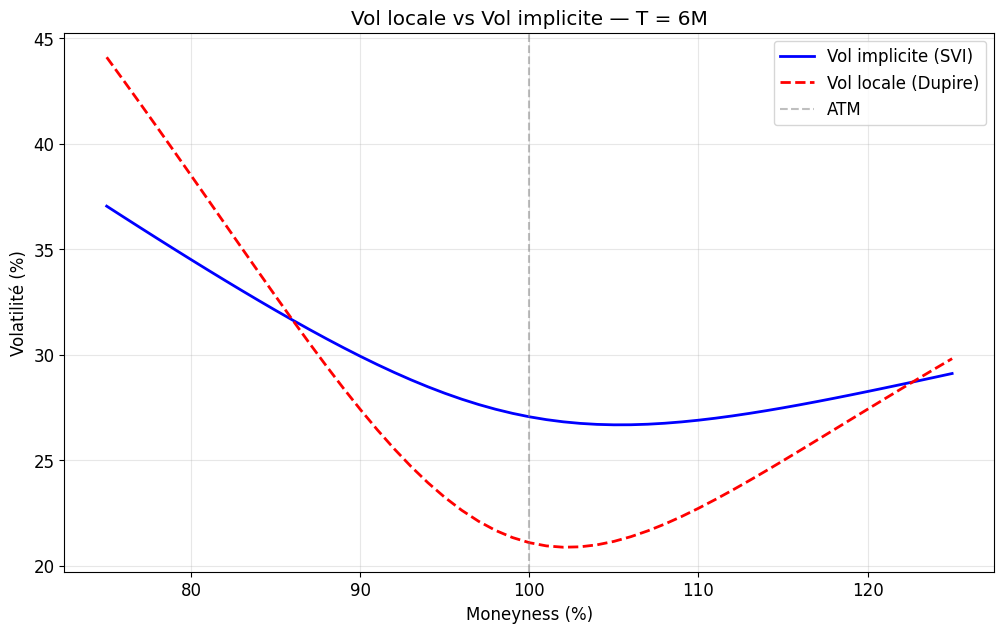

In [15]:
# =============================================================
# SMILE VOL LOCALE vs VOL IMPLICITE — Maturité 6M
# =============================================================

T_plot = 0.5  # 6 mois

vol_loc_6m = [dupire.local_vol(K, T_plot) for K in strikes_plot]
vol_imp_6m = [surface.implied_vol(K, T_plot) for K in strikes_plot]

moneyness = strikes_plot / S0 * 100

plt.figure(figsize=(12, 7))
plt.plot(moneyness, np.array(vol_imp_6m) * 100, 'b-', linewidth=2, label='Vol implicite (SVI)')
plt.plot(moneyness, np.array(vol_loc_6m) * 100, 'r--', linewidth=2, label='Vol locale (Dupire)')
plt.axvline(x=100, color='gray', linestyle='--', alpha=0.5, label='ATM')
plt.xlabel('Moneyness (%)')
plt.ylabel('Volatilité (%)')
plt.title('Vol locale vs Vol implicite — T = 6M')
plt.legend()
plt.show()

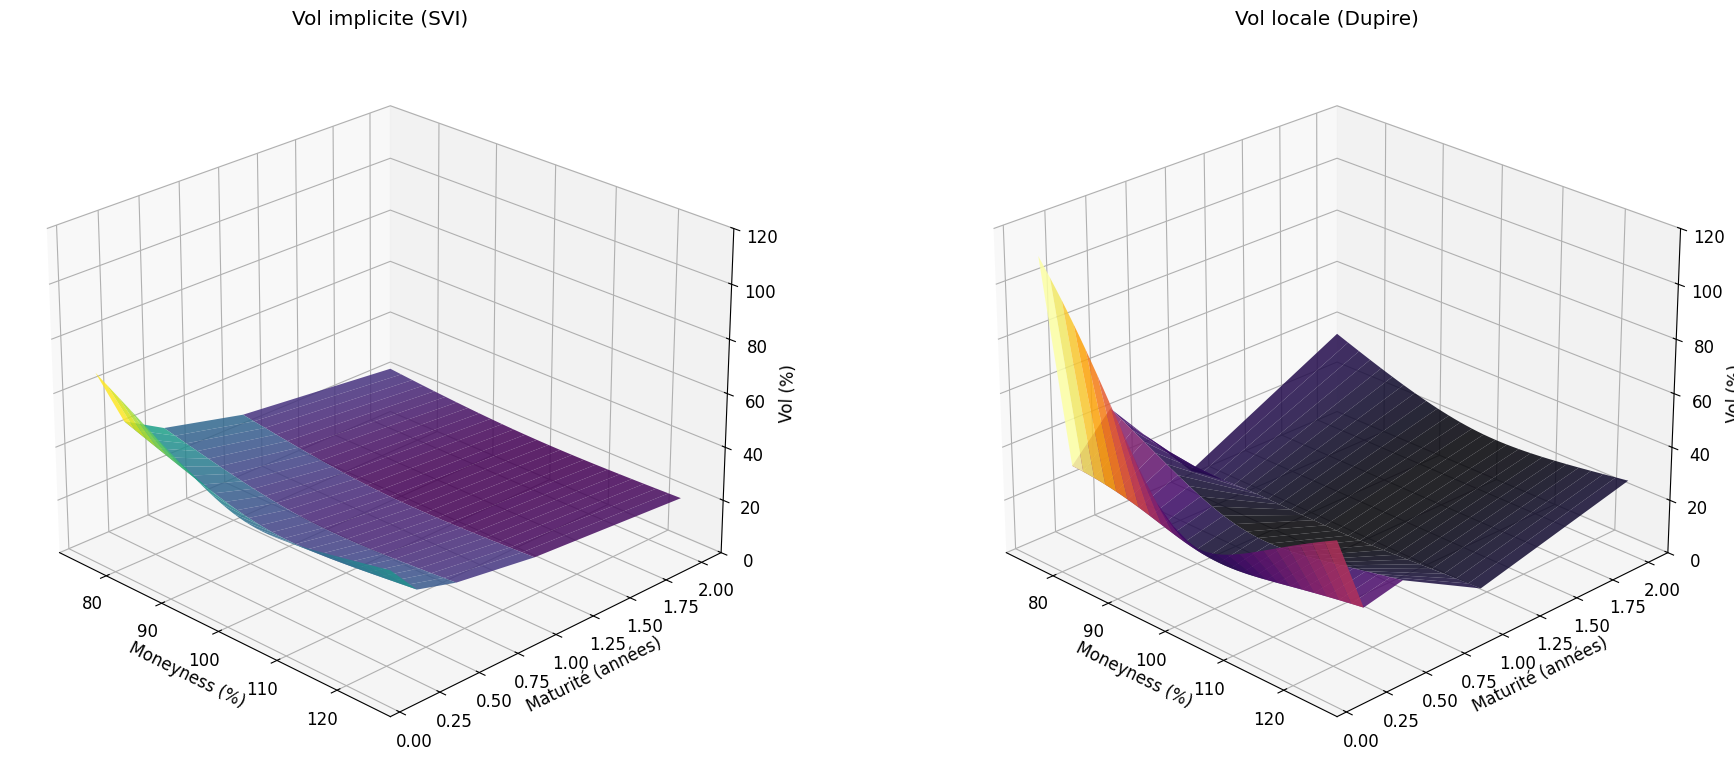

In [16]:
# =============================================================
# SURFACES 3D — Vol locale vs Vol implicite côte à côte
# =============================================================

K_grid, T_grid = np.meshgrid(strikes_plot / S0 * 100, mat_plot)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': '3d'})

# Vol implicite
axes[0].plot_surface(K_grid, T_grid, implied_vol_matrix * 100,
                     cmap='viridis', alpha=0.85, edgecolor='none')
axes[0].set_xlabel('Moneyness (%)')
axes[0].set_ylabel('Maturité (années)')
axes[0].set_zlabel('Vol (%)')
axes[0].set_title('Vol implicite (SVI)')
axes[0].set_zlim(0, 120)
axes[0].view_init(elev=25, azim=-45)

# Vol locale
axes[1].plot_surface(K_grid, T_grid, local_vol_matrix * 100,
                     cmap='inferno', alpha=0.85, edgecolor='none')
axes[1].set_xlabel('Moneyness (%)')
axes[1].set_ylabel('Maturité (années)')
axes[1].set_zlabel('Vol (%)')
axes[1].set_title('Vol locale (Dupire)')
axes[1].set_zlim(0, 120)
axes[1].view_init(elev=25, azim=-45)

plt.tight_layout()
plt.show()

### Interprétation : vol locale vs vol implicite

**Graphique 2D (smile 6M) :**

- Les deux courbes se croisent autour de 87% de moneyness. C'est le point pivot.
- **À gauche du pivot (strikes bas, 75-87%)** : la vol locale (rouge) est au-dessus de la vol implicite (bleue). Dupire dit : "pour reproduire les prix élevés des calls deep ITM à strikes bas, la diffusion instantanée doit être plus forte que ce que la vol implicite moyenne suggère."
- **Au centre et à droite (87-120%)** : la vol locale passe en dessous. Elle descend jusqu'à ~21% ATM alors que la vol implicite est à ~27%. La vol implicite moyenne sur [0, T] ce creux avec les ailes, ce qui la maintient plus haute.
- **L'aile droite (120%+)** : la vol locale remonte et rattrape la vol implicite. Les deux convergent vers ~30%.
- L'amplitude totale de la vol locale (~24 points entre min et max) est plus grande que celle de la vol implicite (~10 points). C'est l'amplification.

**Graphiques 3D (surfaces côte à côte) :**

- **Surface de gauche (vol implicite)** : lisse, régulière, pas de zone extrême. Le pic jaune à gauche monte à ~68%. C'est une surface "sage".
- **Surface de droite (vol locale)** : beaucoup plus accidentée. Le pic jaune en haut à gauche (strikes bas, courte maturité) explose à ~110%. La zone sombre au centre (ATM, longue maturité) descend à ~8%. C'est une surface "nerveuse".
- La comparaison côte à côte sur la même échelle (0-120%) montre visuellement que la vol locale est une version **amplifiée et déformée** de la vol implicite. Dupire "dé-lisse" la surface pour retrouver la diffusion instantanée qui génère les prix observés.
- Le contraste entre les deux surfaces est exactement la raison pour laquelle un BS flat (qui utiliserait une seule valeur pour toute la surface) se trompe sur les options exotiques : il ignore toute cette structure locale.

## 4. Monte Carlo sous volatilité locale

On a maintenant σ_loc(S, t) — la volatilité locale calibrée par Dupire. On va l'utiliser pour simuler des trajectoires du sous-jacent sous la dynamique :

$$dS_t = (r - q) \, S_t \, dt + \sigma_{loc}(S_t, t) \, S_t \, dW_t$$

et pricer des options par espérance risque-neutre : V₀ = e^{-rT} · E[payoff].

**Pourquoi Monte Carlo ?** Les options vanilles ont des formules fermées sous BS. Mais les options barrières (notre objectif final) sont **path-dependent** — leur payoff dépend de toute la trajectoire, pas juste de S_T. Sous vol locale, il n'y a pas de formule fermée pour les barrières. La seule solution est de simuler les trajectoires.

**Le schéma de discrétisation** : on utilise Euler-Maruyama en **log-spot**. Plutôt que de discrétiser dS directement (ce qui peut produire des S négatifs), on discrétise d(ln S) :

$$\ln S_{t+\Delta t} = \ln S_t + \left(r - q - \frac{1}{2}\sigma_{loc}^2(S_t, t)\right)\Delta t + \sigma_{loc}(S_t, t)\sqrt{\Delta t} \; Z$$

où Z ~ N(0,1). En prenant l'exponentielle, on garantit S > 0 à chaque pas.

In [17]:
# =============================================================
# MONTE CARLO SOUS VOLATILITÉ LOCALE — Euler-Maruyama en log-spot
# =============================================================

class MonteCarloLocalVol:
    """
    On simule N trajectoires de S sous la dynamique de vol locale,
    puis on price des options par moyenne des payoffs actualisés.
    """

    def __init__(self, dupire_model, n_paths=100_000, n_steps=252, seed=42):
        self.model = dupire_model
        self.n_paths = n_paths
        self.n_steps = n_steps
        self.rng = np.random.default_rng(seed)

    def simulate_paths(self, T):
        S0 = self.model.S0
        r, q = self.model.r, self.model.q
        dt = T / self.n_steps
        sqrt_dt = np.sqrt(dt)

        # Matrice (n_steps+1 × n_paths) — chaque colonne est une trajectoire
        paths = np.zeros((self.n_steps + 1, self.n_paths))
        paths[0] = S0

        for i in range(self.n_steps):
            t = i * dt
            S = paths[i]

            # σ_loc évalué au milieu du pas (t + dt/2) pour chaque trajectoire
            sigma = np.array([self.model.local_vol(s, t + dt/2) for s in S])

            Z = self.rng.standard_normal(self.n_paths)

            # Euler en log-spot : garantit S > 0
            log_S = np.log(S)
            log_S += (r - q - 0.5 * sigma**2) * dt + sigma * sqrt_dt * Z
            paths[i + 1] = np.exp(log_S)

        return paths

print("MonteCarloLocalVol OK")

MonteCarloLocalVol OK


### Pricing par Monte Carlo

On ajoute deux méthodes de pricing :

1. **Option vanille** : payoff = max(S_T - K, 0) pour un call. On calcule le payoff terminal pour chaque trajectoire et on moyenne. C'est notre test de validation — on pourra comparer le prix MC au prix BS de la surface pour vérifier que la simulation est cohérente.

2. **Option barrière** : même payoff mais conditionné au fait que la trajectoire n'a **jamais** touché la barrière. Pour un down-and-out call avec barrière B : si min(S_t) ≤ B à un moment quelconque, le payoff est annulé.

Pour les deux, on retourne aussi l'**erreur standard** = écart-type du payoff / √N. C'est l'incertitude sur notre estimation MC. Avec 100 000 paths, l'erreur standard est typiquement de l'ordre de quelques centimes.

In [18]:
# =============================================================
# MÉTHODES DE PRICING — Vanille et Barrière
# =============================================================

def mc_price_european(mc, T, K):
    """
    Prix d'un call européen par Monte Carlo.
    On simule les trajectoires, on calcule le payoff terminal, on moyenne.
    """
    paths = mc.simulate_paths(T)
    S_T = paths[-1]
    payoff = np.maximum(S_T - K, 0)

    price = np.exp(-mc.model.r * T) * np.mean(payoff)
    stderr = np.exp(-mc.model.r * T) * np.std(payoff) / np.sqrt(mc.n_paths)
    return price, stderr


def mc_price_barrier(mc, T, K, barrier, barrier_type='down-and-out'):
    """
    Prix d'un call barrière par Monte Carlo.
    On vérifie pour chaque trajectoire si la barrière a été touchée.
    """
    paths = mc.simulate_paths(T)
    S_T = paths[-1]

    # La barrière a-t-elle été touchée ?
    if barrier_type.startswith('down'):
        knocked = np.any(paths <= barrier, axis=0)
    else:
        knocked = np.any(paths >= barrier, axis=0)

    payoff = np.maximum(S_T - K, 0)

    # Appliquer la condition barrière
    if barrier_type.endswith('out'):
        payoff[knocked] = 0     # meurt si touché
    else:
        payoff[~knocked] = 0    # naît seulement si touché

    price = np.exp(-mc.model.r * T) * np.mean(payoff)
    stderr = np.exp(-mc.model.r * T) * np.std(payoff) / np.sqrt(mc.n_paths)
    return price, stderr

print("Fonctions de pricing MC OK")

Fonctions de pricing MC OK


### Test de validation : MC vanille vs prix BS de la surface

Avant de pricer des barrières, on vérifie que notre Monte Carlo est cohérent. On price un call vanille ATM (K=100, T=6M) sous vol locale et on compare au prix BS calculé avec la vol implicite de la surface.

Si Dupire est correctement calibré, les deux doivent donner le **même prix** (à l'erreur MC près). C'est le principe même de la vol locale : elle est construite pour reproduire exactement les prix vanilles.

Ce test est lent (~30 secondes) car on évalue σ_loc pour chaque trajectoire à chaque pas de temps. C'est le prix à payer pour la vol locale — en production on optimiserait avec une grille pré-calculée.

In [19]:
# =============================================================
# VALIDATION : MC sous vol locale vs BS sur la surface
# =============================================================

mc = MonteCarloLocalVol(dupire, n_paths=5_000, n_steps=50, seed=42)

K_test = 100
T_test = 0.5

# Prix MC sous vol locale
prix_mc, stderr_mc = mc_price_european(mc, T_test, K_test)

# Prix BS avec la vol implicite de la surface (notre référence)
prix_bs = surface.call_price(S0, K_test, T_test, r, q)

print(f"Prix MC (vol locale)  = {prix_mc:.4f}  ± {stderr_mc:.4f}")
print(f"Prix BS (vol implicite) = {prix_bs:.4f}")
print(f"Écart                 = {abs(prix_mc - prix_bs):.4f}")
print(f"Écart en stderr       = {abs(prix_mc - prix_bs) / stderr_mc:.1f} σ")

Prix MC (vol locale)  = 7.8042  ± 0.1886
Prix BS (vol implicite) = 7.7769
Écart                 = 0.0274
Écart en stderr       = 0.1 σ


### Optimisation : pré-calcul de la vol locale sur une grille

Le Monte Carlo est correct mais trop lent. Le problème : à chaque pas de temps, pour chaque trajectoire, on appelle `local_vol(S, t)` qui recalcule 5 prix BS via l'interpolateur. Avec 5 000 paths × 50 pas = 250 000 appels, ça prend ~4 minutes.

La solution : **pré-calculer** σ_loc sur une grille (S, t) une seule fois, puis **interpoler** pendant la simulation. Au lieu de recalculer Dupire à chaque appel, on fait un simple lookup dans une grille 2D. C'est exactement ce que font les desks en production.

Le coût passe de 250 000 évaluations de Dupire à ~1 évaluation d'interpolation par appel — un facteur 100x plus rapide.

In [20]:
# =============================================================
# PRÉ-CALCUL DE LA VOL LOCALE SUR UNE GRILLE
# =============================================================

# Grille de spots et de temps sur laquelle on pré-calcule σ_loc
spots_grid = np.linspace(60, 150, 91)    # S de 60 à 150 (couvre les trajectoires possibles)
times_grid = np.linspace(0.01, 2.1, 100) # t de ~0 à 2Y (on évite t=0 exact)

# On remplit la matrice σ_loc(t, S) une seule fois
local_vol_grid = np.zeros((len(times_grid), len(spots_grid)))

for i, t in enumerate(times_grid):
    for j, s in enumerate(spots_grid):
        local_vol_grid[i, j] = dupire.local_vol(s, t)

# On construit un interpolateur 2D rapide (même principe que pour la vol implicite)
local_vol_interp = RectBivariateSpline(times_grid, spots_grid, local_vol_grid, kx=3, ky=3)

def fast_local_vol(S, t):
    """σ_loc(S, t) par interpolation sur la grille pré-calculée."""
    # On clamp S et t dans les bornes de la grille pour éviter l'extrapolation
    S_clip = np.clip(S, spots_grid[0], spots_grid[-1])
    t_clip = np.clip(t, times_grid[0], times_grid[-1])
    return local_vol_interp(t_clip, S_clip, grid=False)

print(f"Grille pré-calculée : {len(times_grid)} temps × {len(spots_grid)} spots")
print("Pré-calcul terminé")

Grille pré-calculée : 100 temps × 91 spots
Pré-calcul terminé


In [21]:
# =============================================================
# MONTE CARLO RAPIDE — Utilise la grille pré-calculée
# =============================================================

class MonteCarloFast:
    """
    Même logique qu'avant mais on utilise fast_local_vol
    au lieu de dupire.local_vol. La vol est interpolée sur la
    grille pré-calculée au lieu d'être recalculée à chaque appel.
    """

    def __init__(self, S0, r, q, n_paths=100_000, n_steps=252, seed=42):
        self.S0 = S0
        self.r = r
        self.q = q
        self.n_paths = n_paths
        self.n_steps = n_steps
        self.rng = np.random.default_rng(seed)

    def simulate_paths(self, T):
        dt = T / self.n_steps
        sqrt_dt = np.sqrt(dt)

        paths = np.zeros((self.n_steps + 1, self.n_paths))
        paths[0] = self.S0

        for i in range(self.n_steps):
            t = i * dt
            S = paths[i]

            # Évaluation vectorisée sur toutes les trajectoires d'un coup
            sigma = fast_local_vol(S, np.full_like(S, t + dt/2))

            Z = self.rng.standard_normal(self.n_paths)
            log_S = np.log(S)
            log_S += (self.r - self.q - 0.5 * sigma**2) * dt + sigma * sqrt_dt * Z
            paths[i + 1] = np.exp(log_S)

        return paths

# Test de vitesse : 50 000 paths × 252 pas
mc_fast = MonteCarloFast(S0, r, q, n_paths=50_000, n_steps=252, seed=42)

import time
t0 = time.time()
paths = mc_fast.simulate_paths(0.5)
t1 = time.time()

print(f"50 000 paths × 252 pas en {t1 - t0:.1f} secondes")
print(f"Shape des trajectoires : {paths.shape}")

50 000 paths × 252 pas en 4.2 secondes
Shape des trajectoires : (253, 50000)


In [22]:
# =============================================================
# REVALIDATION : MC rapide vs BS de la surface
# =============================================================

K_test = 100
T_test = 0.5

paths = mc_fast.simulate_paths(T_test)
S_T = paths[-1]
payoff = np.maximum(S_T - K_test, 0)

prix_mc = np.exp(-r * T_test) * np.mean(payoff)
stderr = np.exp(-r * T_test) * np.std(payoff) / np.sqrt(mc_fast.n_paths)
prix_bs = surface.call_price(S0, K_test, T_test, r, q)

print(f"Prix MC (vol locale)    = {prix_mc:.4f}  ± {stderr:.4f}")
print(f"Prix BS (vol implicite) = {prix_bs:.4f}")
print(f"Écart                   = {abs(prix_mc - prix_bs):.4f}")
print(f"Écart en stderr         = {abs(prix_mc - prix_bs) / stderr:.1f} σ")

Prix MC (vol locale)    = 7.7905  ± 0.0586
Prix BS (vol implicite) = 7.7769
Écart                   = 0.0137
Écart en stderr         = 0.2 σ


## 5. Options barrières — Local Vol vs BS flat

C'est le point d'arrivée du projet. On va pricer un **down-and-out call** (DOC) sous deux modèles :

1. **BS flat** : σ = constante = vol ATM de la surface. C'est ce que ferait un quant paresseux.
2. **Vol locale** : σ = σ_loc(S, t) calibré par Dupire sur toute la surface.

On va aussi comparer au **prix analytique BS** (formule fermée du DOC sous vol constante) pour valider le MC.

L'enjeu : montrer que le modèle de vol fait une **vraie différence** sur les barrières. Deux modèles calibrés sur les mêmes prix vanilles donnent des prix de barrières différents — c'est ce qui justifie tout le travail qu'on a fait.

In [23]:
# =============================================================
# PRICING BARRIÈRE : VOL LOCALE vs BS FLAT vs ANALYTIQUE
# =============================================================

K = 100
T = 0.5
B = 85  # barrière à 85% du spot

# --- 1. Prix analytique BS (formule fermée, vol constante = vol ATM) ---
vol_atm = surface.implied_vol(100, T)

def bs_down_and_out_call(S, K, T, r, q, sigma, B):
    """Formule fermée du DOC sous BS. Valide pour B < K."""
    if B >= S:
        return 0.0
    lam = (r - q + 0.5 * sigma**2) / (sigma**2)
    C_vanilla = bs_call_price(S, K, T, r, q, sigma)
    C_reflected = bs_call_price(B**2 / S, K, T, r, q, sigma)
    return C_vanilla - (B / S) ** (2 * lam) * C_reflected

prix_analytique = bs_down_and_out_call(S0, K, T, r, q, vol_atm, B)

# --- 2. MC sous BS flat (vol constante) ---
mc_flat = MonteCarloFast(S0, r, q, n_paths=50_000, n_steps=252, seed=42)

# On remplace temporairement fast_local_vol par une vol constante
_original_flv = fast_local_vol
def flat_vol(S, t):
    return np.full_like(S, vol_atm)

fast_local_vol = flat_vol
paths_flat = mc_flat.simulate_paths(T)
S_T_flat = paths_flat[-1]
knocked_flat = np.any(paths_flat <= B, axis=0)
payoff_flat = np.maximum(S_T_flat - K, 0)
payoff_flat[knocked_flat] = 0
prix_bs_mc = np.exp(-r * T) * np.mean(payoff_flat)
stderr_bs = np.exp(-r * T) * np.std(payoff_flat) / np.sqrt(50_000)

# --- 3. MC sous vol locale ---
fast_local_vol = _original_flv
mc_lv = MonteCarloFast(S0, r, q, n_paths=50_000, n_steps=252, seed=42)
paths_lv = mc_lv.simulate_paths(T)
S_T_lv = paths_lv[-1]
knocked_lv = np.any(paths_lv <= B, axis=0)
payoff_lv = np.maximum(S_T_lv - K, 0)
payoff_lv[knocked_lv] = 0
prix_lv_mc = np.exp(-r * T) * np.mean(payoff_lv)
stderr_lv = np.exp(-r * T) * np.std(payoff_lv) / np.sqrt(50_000)

print(f"Down-and-Out Call : K={K}, B={B}, T={T}Y")
print(f"Vol ATM utilisée pour BS flat : {vol_atm:.2%}")
print()
print(f"BS analytique (vol flat)  = {prix_analytique:.4f}")
print(f"MC BS flat                = {prix_bs_mc:.4f}  ± {stderr_bs:.4f}")
print(f"MC Vol locale (Dupire)    = {prix_lv_mc:.4f}  ± {stderr_lv:.4f}")
print()
diff_pct = (prix_lv_mc - prix_bs_mc) / prix_bs_mc * 100
print(f"Écart LV vs BS flat       = {diff_pct:+.1f}%")

Down-and-Out Call : K=100, B=85, T=0.5Y
Vol ATM utilisée pour BS flat : 27.06%

BS analytique (vol flat)  = 7.5224
MC BS flat                = 7.5148  ± 0.0565
MC Vol locale (Dupire)    = 7.3142  ± 0.0585

Écart LV vs BS flat       = -2.7%


### Interprétation des résultats

**Validation du MC :** le MC BS flat (7.5148) est très proche de la formule analytique BS (7.5224) — l'écart est de 0.0076, soit environ 0.1%. Ça confirme que notre simulateur fonctionne correctement.

**L'écart qui compte :** le prix sous vol locale (7.3142) est **2.7% en dessous** du prix BS flat (7.5148). Pour un notionnel de 10 millions, ça fait ~200 000 de différence de prix. Ce n'est pas du bruit — c'est un effet systématique du modèle de vol.

**Pourquoi la vol locale donne un prix plus bas ici ?** Avec une barrière à 85, les trajectoires qui knockent sont celles qui descendent vers B = 85. Dans cette zone (moneyness ~85%), on a vu sur nos graphiques que la vol locale est **plus élevée** que la vol ATM plate (la vol locale monte dans l'aile gauche). Une vol plus élevée dans la zone de la barrière signifie plus de trajectoires qui touchent la barrière, donc plus de knock-outs, donc un prix plus bas.

BS flat utilise 27% partout. La vol locale utilise ~32-35% autour de S = 85. Elle "voit" plus de risque de toucher la barrière que BS flat — d'où le prix inférieur.

**C'est exactement le problème que Dupire résout :** un trader qui pricerait cette barrière avec BS flat la surévaluerait de 2.7%. Avec la vol locale calibrée sur le smile, on obtient un prix plus réaliste qui tient compte de la dynamique locale du sous-jacent.

Pour une barrière plus proche du spot (par exemple B = 95), l'écart serait encore plus grand. On va vérifier.

In [24]:
# =============================================================
# IMPACT DE LA BARRIÈRE : écart LV vs BS flat pour différents B
# =============================================================

barriers = [70, 75, 80, 85, 90, 95]
results = []

for B_test in barriers:
    # MC vol locale
    mc_lv = MonteCarloFast(S0, r, q, n_paths=50_000, n_steps=252, seed=42)
    paths_lv = mc_lv.simulate_paths(T)
    knocked_lv = np.any(paths_lv <= B_test, axis=0)
    payoff_lv = np.maximum(paths_lv[-1] - K, 0)
    payoff_lv[knocked_lv] = 0
    prix_lv = np.exp(-r * T) * np.mean(payoff_lv)

    # MC BS flat
    fast_local_vol = flat_vol
    mc_fl = MonteCarloFast(S0, r, q, n_paths=50_000, n_steps=252, seed=42)
    paths_fl = mc_fl.simulate_paths(T)
    knocked_fl = np.any(paths_fl <= B_test, axis=0)
    payoff_fl = np.maximum(paths_fl[-1] - K, 0)
    payoff_fl[knocked_fl] = 0
    prix_fl = np.exp(-r * T) * np.mean(payoff_fl)

    fast_local_vol = _original_flv

    diff = (prix_lv - prix_fl) / prix_fl * 100 if prix_fl > 0.01 else 0
    results.append((B_test, prix_fl, prix_lv, diff))
    print(f"B={B_test:3d}  |  BS flat = {prix_fl:.4f}  |  Vol locale = {prix_lv:.4f}  |  Écart = {diff:+.1f}%")

B= 70  |  BS flat = 7.8069  |  Vol locale = 7.8101  |  Écart = +0.0%
B= 75  |  BS flat = 7.8010  |  Vol locale = 7.7559  |  Écart = -0.6%
B= 80  |  BS flat = 7.7610  |  Vol locale = 7.6314  |  Écart = -1.7%
B= 85  |  BS flat = 7.5148  |  Vol locale = 7.3142  |  Écart = -2.7%
B= 90  |  BS flat = 6.6764  |  Vol locale = 6.5420  |  Écart = -2.0%
B= 95  |  BS flat = 4.5698  |  Vol locale = 4.6590  |  Écart = +2.0%


### Interprétation : impact de la barrière

Les résultats montrent trois régimes :

**B = 70 (barrière très loin) : écart ≈ 0%**
La barrière est à 30% sous le spot. Quasiment aucune trajectoire ne descend aussi bas en 6 mois, quel que soit le modèle de vol. Le DOC se comporte comme un call vanille — pas de différence entre les modèles.

**B = 75 à 90 (barrière intermédiaire) : vol locale < BS flat (-0.6% à -2.7%)**
C'est la zone où l'écart est maximal autour de B = 85. Dans cette zone de moneyness (75-90%), la vol locale est **plus élevée** que la vol ATM flat (on l'a vu sur le graphique du smile). Plus de vol autour de la barrière = plus de chances de knocker = prix plus bas. L'écart pic est à -2.7% pour B = 85.

**B = 95 (barrière proche du spot) : vol locale > BS flat (+2.0%)**
Le signe s'inverse. C'est contre-intuitif au premier abord. Mais on a vu sur le graphique 2D que la vol locale **descend en dessous** de la vol implicite entre 95% et 115% de moneyness (~21% contre ~27%). Autour de S = 95, la vol locale est plus basse que la vol ATM flat. Moins de vol = moins de chances de knocker = prix plus haut.

**Ce qu'il faut retenir :** l'écart entre les deux modèles n'est pas constant — il dépend de la position de la barrière par rapport à la structure locale de la volatilité. C'est exactement pourquoi un BS flat est dangereux pour pricer des barrières : selon le placement de la barrière, il peut **surévaluer ou sous-évaluer** le produit. La vol locale, elle, utilise la bonne vol au bon endroit.

## 6. Greeks par bump-and-reprice

Sous vol locale, on n'a pas de formules fermées pour les Greeks. On les calcule par **différences finies** : on perturbe un paramètre d'entrée, on re-price, et on observe la variation. C'est la méthode standard en production pour les modèles numériques.

On va calculer :
- **Delta** = ∂V/∂S — de combien bouge le prix si le spot bouge de 1
- **Gamma** = ∂²V/∂S² — de combien bouge le delta si le spot bouge de 1

On les calcule pour le **DOC sous vol locale** et on compare au DOC sous BS flat. La différence entre les deux profils de Greeks est aussi importante que la différence de prix — c'est ce qui impacte le hedging au quotidien.

**Point technique important** : on utilise le **même seed** pour les simulations bump-up et bump-down. Sinon le bruit MC noie complètement le signal des différences finies.

In [25]:
# =============================================================
# GREEKS DU DOC : DELTA ET GAMMA par bump-and-reprice
# =============================================================

def compute_doc_greeks(S0_base, K, T, B, vol_func, bump=1.0, n_paths=5_000):
    """
    Delta et Gamma d'un DOC par différences finies centrées.
    vol_func : soit _original_flv (vol locale) soit flat_vol (BS flat)
    On fixe le seed à chaque simulation pour que le bruit MC se compense.
    """
    global fast_local_vol
    fast_local_vol = vol_func

    prices = {}
    for label, S_shifted in [('up', S0_base + bump), ('mid', S0_base), ('dn', S0_base - bump)]:
        mc = MonteCarloFast(S_shifted, r, q, n_paths=n_paths, n_steps=252, seed=42)
        paths = mc.simulate_paths(T)
        knocked = np.any(paths <= B, axis=0)
        payoff = np.maximum(paths[-1] - K, 0)
        payoff[knocked] = 0
        prices[label] = np.exp(-r * T) * np.mean(payoff)

    delta = (prices['up'] - prices['dn']) / (2 * bump)
    gamma = (prices['up'] - 2 * prices['mid'] + prices['dn']) / (bump**2)
    return delta, gamma

# Calcul sur une grille de spots pour tracer le profil
spots = np.arange(88, 116, 1.0)
K, T, B = 100, 0.5, 85

deltas_lv, gammas_lv = [], []
deltas_flat, gammas_flat = [], []

for S_test in spots:
    d, g = compute_doc_greeks(S_test, K, T, B, _original_flv, n_paths=20_000)
    deltas_lv.append(d)
    gammas_lv.append(g)

    d, g = compute_doc_greeks(S_test, K, T, B, flat_vol, n_paths=20_000)
    deltas_flat.append(d)
    gammas_flat.append(g)

    print(f"S={S_test:.0f} done")

# On remet la vol locale par défaut
fast_local_vol = _original_flv
print("Greeks calculés")

S=88 done
S=89 done
S=90 done
S=91 done
S=92 done
S=93 done
S=94 done
S=95 done
S=96 done
S=97 done
S=98 done
S=99 done
S=100 done
S=101 done
S=102 done
S=103 done
S=104 done
S=105 done
S=106 done
S=107 done
S=108 done
S=109 done
S=110 done
S=111 done
S=112 done
S=113 done
S=114 done
S=115 done
Greeks calculés


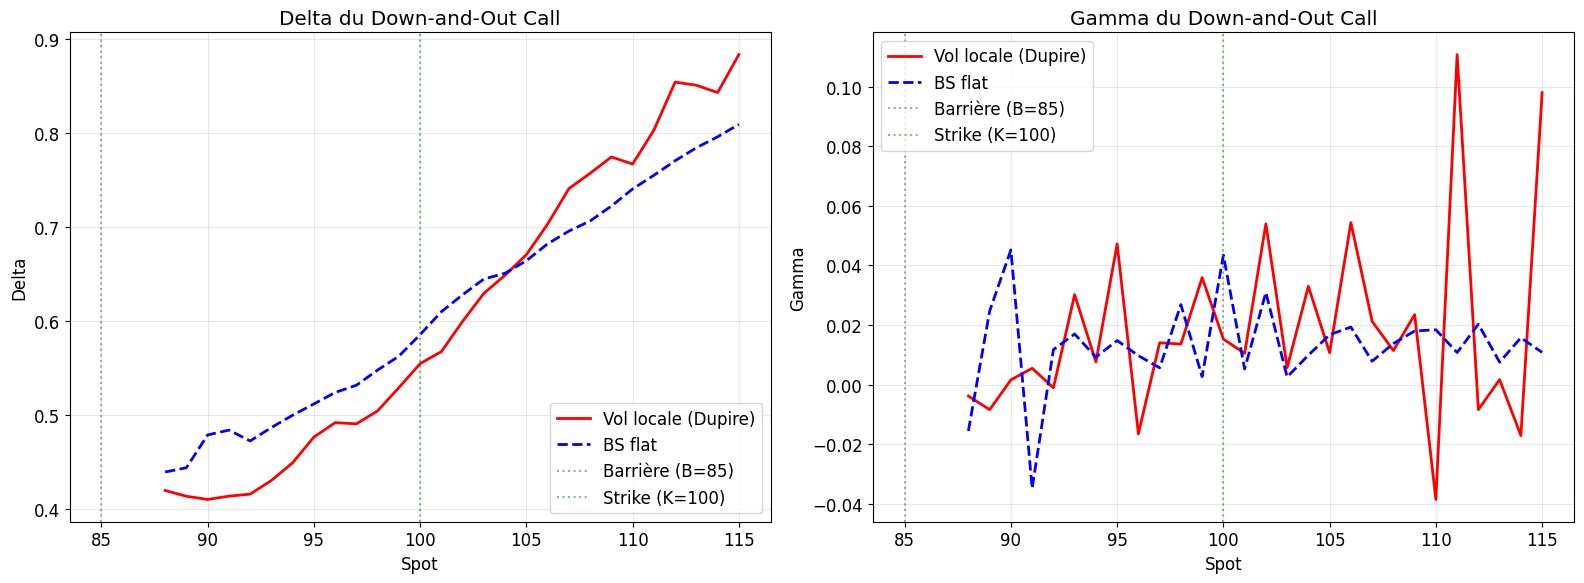

In [26]:
# =============================================================
# PROFILS DE DELTA ET GAMMA — Vol locale vs BS flat
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delta
axes[0].plot(spots, deltas_lv, 'r-', linewidth=2, label='Vol locale (Dupire)')
axes[0].plot(spots, deltas_flat, 'b--', linewidth=2, label='BS flat')
axes[0].axvline(x=B, color='gray', linestyle=':', alpha=0.7, label=f'Barrière (B={B})')
axes[0].axvline(x=K, color='green', linestyle=':', alpha=0.5, label=f'Strike (K={K})')
axes[0].set_xlabel('Spot')
axes[0].set_ylabel('Delta')
axes[0].set_title('Delta du Down-and-Out Call')
axes[0].legend()

# Gamma
axes[1].plot(spots, gammas_lv, 'r-', linewidth=2, label='Vol locale (Dupire)')
axes[1].plot(spots, gammas_flat, 'b--', linewidth=2, label='BS flat')
axes[1].axvline(x=B, color='gray', linestyle=':', alpha=0.7, label=f'Barrière (B={B})')
axes[1].axvline(x=K, color='green', linestyle=':', alpha=0.5, label=f'Strike (K={K})')
axes[1].set_xlabel('Spot')
axes[1].set_ylabel('Gamma')
axes[1].set_title('Gamma du Down-and-Out Call')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interprétation des Greeks

**Delta (graphique de gauche) :**

- Les deux courbes sont croissantes : plus le spot est haut, plus le DOC a de valeur, plus le delta est élevé. C'est logique — un call deep ITM a un delta proche de 1.
- Près de la barrière (S → 85), le delta **chute** pour les deux modèles. L'option risque de mourir, donc sa sensibilité au spot diminue.
- La vol locale (rouge) donne un delta systématiquement **plus bas** que BS flat (bleu) dans la zone 88-103. C'est cohérent avec le prix : le modèle de vol locale "voit" plus de risque de knock-out (vol plus élevée près de la barrière), donc l'option est moins sensible au spot — elle a plus de chances de ne rien valoir.
- Au-dessus de S = 105, la vol locale donne un delta **plus haut**. Loin de la barrière, le DOC se comporte comme un call vanille et la vol locale plus basse dans cette zone donne un delta plus élevé.

**Gamma (graphique de droite) :**

- Le graphique est très bruité. C'est une limite connue du bump-and-reprice : le gamma est une **dérivée seconde**, ce qui amplifie le bruit MC. Avec 5 000 paths, le signal/bruit est insuffisant.
- On distingue quand même un gamma négatif du BS flat autour de S = 93-97. Un gamma négatif pour un DOC est caractéristique : quand le spot se rapproche de la barrière, le delta chute brutalement — la courbure est négative.
- Pour obtenir un gamma propre, il faudrait 50 000+ paths ou utiliser des techniques de réduction de variance (antithétiques, contrôle variate). C'est une amélioration possible du projet.

## 7. Convergence Monte Carlo

Dernier point : on vérifie que notre estimateur MC converge bien en 1/√N. On price le DOC sous vol locale avec un nombre croissant de paths et on trace le prix ± 2 erreurs standard. On s'attend à voir l'intervalle de confiance se resserrer autour de la vraie valeur quand N augmente.

C'est un graphique classique dans tout projet MC — il montre que les résultats sont fiables et qu'on sait quantifier notre incertitude.


In [27]:
# =============================================================
# CONVERGENCE MC — Prix du DOC en fonction du nombre de paths
# =============================================================

K, T, B = 100, 0.5, 85
path_counts = [500, 1000, 2000, 5000, 10000, 20000, 50000]

prix_list = []
stderr_list = []

fast_local_vol = _original_flv

for N in path_counts:
    mc_conv = MonteCarloFast(S0, r, q, n_paths=N, n_steps=252, seed=42)
    paths = mc_conv.simulate_paths(T)
    knocked = np.any(paths <= B, axis=0)
    payoff = np.maximum(paths[-1] - K, 0)
    payoff[knocked] = 0

    prix = np.exp(-r * T) * np.mean(payoff)
    stderr = np.exp(-r * T) * np.std(payoff) / np.sqrt(N)

    prix_list.append(prix)
    stderr_list.append(stderr)
    print(f"N={N:6d}  |  Prix = {prix:.4f}  ± {stderr:.4f}")

prix_list = np.array(prix_list)
stderr_list = np.array(stderr_list)

N=   500  |  Prix = 7.1805  ± 0.5839
N=  1000  |  Prix = 7.3421  ± 0.4226
N=  2000  |  Prix = 7.3783  ± 0.2940
N=  5000  |  Prix = 7.6351  ± 0.1898
N= 10000  |  Prix = 7.3880  ± 0.1316
N= 20000  |  Prix = 7.4385  ± 0.0945
N= 50000  |  Prix = 7.3142  ± 0.0585


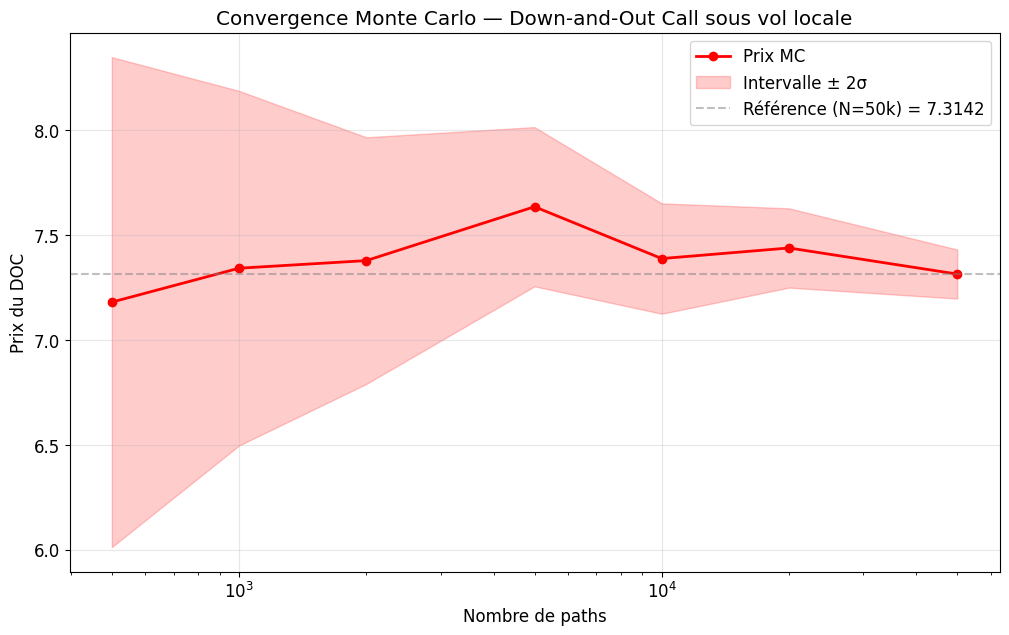

In [28]:
# =============================================================
# GRAPHIQUE DE CONVERGENCE
# =============================================================

plt.figure(figsize=(12, 7))

plt.plot(path_counts, prix_list, 'r-o', linewidth=2, label='Prix MC')
plt.fill_between(path_counts,
                 prix_list - 2 * stderr_list,
                 prix_list + 2 * stderr_list,
                 color='red', alpha=0.2, label='Intervalle ± 2σ')
plt.axhline(y=prix_list[-1], color='gray', linestyle='--', alpha=0.5, label=f'Référence (N=50k) = {prix_list[-1]:.4f}')

plt.xlabel('Nombre de paths')
plt.ylabel('Prix du DOC')
plt.title('Convergence Monte Carlo — Down-and-Out Call sous vol locale')
plt.xscale('log')
plt.legend()
plt.show()

### Interprétation de la convergence

Le graphique montre le comportement classique d'un estimateur Monte Carlo :

- **L'intervalle de confiance (zone rose) se resserre** quand N augmente. À 500 paths, il couvre de 6.0 à 8.3 — une incertitude de ±1.2 sur le prix. À 50 000 paths, il ne couvre plus que de 7.2 à 7.4 — une incertitude de ±0.12. C'est bien la convergence en 1/√N : pour diviser l'erreur par 10, il faut multiplier N par 100.

- **Le prix se stabilise** autour de 7.31 à partir de ~10 000 paths. Les fluctuations à faible N (le pic à 7.63 pour N=5 000 par exemple) sont du bruit statistique — on tire peu de trajectoires, donc certaines réalisations extrêmes pèsent lourd dans la moyenne.

- **La ligne de référence (7.3142)** correspond à notre meilleure estimation avec 50 000 paths. Tous les prix à N ≥ 10 000 sont à l'intérieur de leur propre intervalle de confiance autour de cette valeur — c'est cohérent.

**Limites :** avec 50 000 paths, on a encore une erreur standard de 0.06, soit ~0.8% du prix. Pour une application en production, on viserait 200 000+ paths (erreur < 0.03) avec les optimisations qu'on a mises en place (grille pré-calculée). Des techniques de réduction de variance (variables antithétiques, contrôle variate par le prix BS flat) permettraient de gagner encore un facteur 2-3 sur la précision sans augmenter N.

## 8. Risk Monitoring & P&L Diagnostics


The previous sections built and validated a local volatility pricing pipeline for barrier options.

This section adds a desk-oriented risk monitoring layer. The objective is no longer only to compute a theoretical price, but to monitor the main risk dimensions of the down-and-out call:

- mark-to-model value under local volatility;
- comparison with Black-Scholes flat volatility to quantify model risk;
- knock-out probability;
- spot stress and full revaluation P&L;
- Delta-Gamma P&L approximation;
- barrier stress.

This is not a production risk engine and does not use historical market surfaces yet. It is a first risk diagnostic layer built directly on top of the existing Monte Carlo pricer.

In [29]:
# =============================================================
# RISK MONITORING — Configuration reproductible
# =============================================================

# Produit de référence : down-and-out call
RISK_SPOT = S0
RISK_STRIKE = 100
RISK_MATURITY = 0.5
RISK_BARRIER = 85

# Paramètres Monte Carlo communs à toute la section Risk Monitoring
RISK_N_PATHS = 30_000
RISK_N_STEPS = 252
RISK_SEED = 42

# Volatilité flat de référence pour le modèle Black-Scholes.
# On reprend la volatilité implicite ATM de la surface au même horizon.
RISK_FLAT_VOL = surface.implied_vol(RISK_SPOT, RISK_MATURITY)

def risk_flat_vol(S, t):
    """
    Volatilité constante utilisée comme benchmark Black-Scholes flat-vol.

    Cette fonction a la même signature que fast_local_vol afin de pouvoir
    être utilisée directement dans MonteCarloFast.
    """
    return np.full_like(S, RISK_FLAT_VOL)


print("Risk Monitoring configuration")
print("-----------------------------")
print(f"Spot initial        : {RISK_SPOT}")
print(f"Strike              : {RISK_STRIKE}")
print(f"Maturity            : {RISK_MATURITY}Y")
print(f"Barrier             : {RISK_BARRIER}")
print(f"MC paths            : {RISK_N_PATHS:,}")
print(f"MC steps            : {RISK_N_STEPS}")
print(f"Seed                : {RISK_SEED}")
print(f"Flat vol benchmark  : {RISK_FLAT_VOL:.2%}")

Risk Monitoring configuration
-----------------------------
Spot initial        : 100
Strike              : 100
Maturity            : 0.5Y
Barrier             : 85
MC paths            : 30,000
MC steps            : 252
Seed                : 42
Flat vol benchmark  : 27.06%


In [30]:
# =============================================================
# RISK MONITORING — Full revaluation function
# =============================================================

def price_down_and_out_call_full_revaluation(
    spot,
    strike,
    maturity,
    barrier,
    volatility_function,
    n_paths,
    n_steps,
    seed
):
    """
    Full revaluation Monte Carlo d'un down-and-out call.

    Cette fonction est volontairement atomique :
    - elle simule les trajectoires sous la fonction de volatilité donnée ;
    - elle applique la condition de knock-out ;
    - elle retourne le prix, l'erreur standard et la probabilité de knock-out.

    Parameters
    ----------
    spot : float
        Spot courant ou spot sous scénario.
    strike : float
        Strike du call.
    maturity : float
        Maturité en années.
    barrier : float
        Barrière down-and-out.
    volatility_function : callable
        Fonction de volatilité utilisée par MonteCarloFast.
        Exemples :
        - _original_flv pour la volatilité locale ;
        - risk_flat_vol pour le benchmark Black-Scholes flat-vol.
    n_paths : int
        Nombre de trajectoires Monte Carlo.
    n_steps : int
        Nombre de pas de temps.
    seed : int
        Seed Monte Carlo pour assurer la reproductibilité.

    Returns
    -------
    dict
        Dictionnaire contenant :
        - price ;
        - standard_error ;
        - knock_out_probability ;
        - survival_probability ;
        - mean_terminal_spot.
    """
    global fast_local_vol

    previous_fast_local_vol = fast_local_vol
    fast_local_vol = volatility_function

    try:
        # Si le spot est déjà sous la barrière, le produit est désactivé.
        if spot <= barrier:
            return {
                "price": 0.0,
                "standard_error": 0.0,
                "knock_out_probability": 1.0,
                "survival_probability": 0.0,
                "mean_terminal_spot": spot
            }

        monte_carlo_engine = MonteCarloFast(
            spot,
            r,
            q,
            n_paths=n_paths,
            n_steps=n_steps,
            seed=seed
        )

        simulated_paths = monte_carlo_engine.simulate_paths(maturity)
        terminal_spots = simulated_paths[-1]

        has_knocked_out = np.any(simulated_paths <= barrier, axis=0)

        payoff = np.maximum(terminal_spots - strike, 0.0)
        payoff[has_knocked_out] = 0.0

        discounted_payoff = np.exp(-r * maturity) * payoff

        price = np.mean(discounted_payoff)
        standard_error = np.std(discounted_payoff) / np.sqrt(n_paths)
        knock_out_probability = np.mean(has_knocked_out)

        return {
            "price": price,
            "standard_error": standard_error,
            "knock_out_probability": knock_out_probability,
            "survival_probability": 1.0 - knock_out_probability,
            "mean_terminal_spot": np.mean(terminal_spots)
        }

    finally:
        # Important : on remet toujours la fonction de volatilité initiale.
        fast_local_vol = previous_fast_local_vol

8.1 Risk Snapshot — Local Vol vs Black-Scholes Flat

In [31]:
# =============================================================
# RISK MONITORING — Risk snapshot
# =============================================================

local_vol_snapshot = price_down_and_out_call_full_revaluation(
    spot=RISK_SPOT,
    strike=RISK_STRIKE,
    maturity=RISK_MATURITY,
    barrier=RISK_BARRIER,
    volatility_function=_original_flv,
    n_paths=RISK_N_PATHS,
    n_steps=RISK_N_STEPS,
    seed=RISK_SEED
)

flat_vol_snapshot = price_down_and_out_call_full_revaluation(
    spot=RISK_SPOT,
    strike=RISK_STRIKE,
    maturity=RISK_MATURITY,
    barrier=RISK_BARRIER,
    volatility_function=risk_flat_vol,
    n_paths=RISK_N_PATHS,
    n_steps=RISK_N_STEPS,
    seed=RISK_SEED
)

model_risk_absolute = local_vol_snapshot["price"] - flat_vol_snapshot["price"]
model_risk_relative = model_risk_absolute / flat_vol_snapshot["price"]

print("Risk Snapshot — Down-and-Out Call")
print("=================================")
print()
print(f"{'Metric':<35} | {'Local Vol':>12} | {'BS Flat Vol':>12}")
print("-" * 66)
print(f"{'Price':<35} | {local_vol_snapshot['price']:>12.4f} | {flat_vol_snapshot['price']:>12.4f}")
print(f"{'Monte Carlo standard error':<35} | {local_vol_snapshot['standard_error']:>12.4f} | {flat_vol_snapshot['standard_error']:>12.4f}")
print(f"{'Knock-out probability':<35} | {local_vol_snapshot['knock_out_probability']:>12.2%} | {flat_vol_snapshot['knock_out_probability']:>12.2%}")
print(f"{'Survival probability':<35} | {local_vol_snapshot['survival_probability']:>12.2%} | {flat_vol_snapshot['survival_probability']:>12.2%}")
print(f"{'Mean terminal spot':<35} | {local_vol_snapshot['mean_terminal_spot']:>12.4f} | {flat_vol_snapshot['mean_terminal_spot']:>12.4f}")
print()
print("Model Risk")
print("----------")
print(f"Local Vol price - BS Flat price : {model_risk_absolute:+.4f}")
print(f"Relative model difference       : {model_risk_relative:+.2%}")

Risk Snapshot — Down-and-Out Call

Metric                              |    Local Vol |  BS Flat Vol
------------------------------------------------------------------
Price                               |       7.3071 |       7.5347
Monte Carlo standard error          |       0.0752 |       0.0726
Knock-out probability               |       37.72% |       39.72%
Survival probability                |       62.28% |       60.28%
Mean terminal spot                  |     100.5923 |     100.5944

Model Risk
----------
Local Vol price - BS Flat price : -0.2276
Relative model difference       : -3.02%


In [32]:
# =============================================================
# RISK MONITORING — Model risk significance check
# =============================================================

combined_standard_error = np.sqrt(
    local_vol_snapshot["standard_error"]**2
    + flat_vol_snapshot["standard_error"]**2
)

model_risk_z_score = model_risk_absolute / combined_standard_error

print("Model Risk Significance Check")
print("=============================")
print()
print(f"Model difference        : {model_risk_absolute:+.4f}")
print(f"Combined MC std error   : {combined_standard_error:.4f}")
print(f"Difference / MC error   : {model_risk_z_score:+.2f} standard errors")
print()

if abs(model_risk_z_score) < 2:
    print("Interpretation:")
    print("The model difference is visible but still close to the Monte Carlo noise level.")
    print("A larger number of paths would be useful before making a strong conclusion.")
else:
    print("Interpretation:")
    print("The model difference is larger than the combined Monte Carlo noise level.")
    print("The local volatility vs flat volatility gap is therefore economically and numerically meaningful.")

Model Risk Significance Check

Model difference        : -0.2276
Combined MC std error   : 0.1046
Difference / MC error   : -2.18 standard errors

Interpretation:
The model difference is larger than the combined Monte Carlo noise level.
The local volatility vs flat volatility gap is therefore economically and numerically meaningful.


In [33]:
# =============================================================
# RISK MONITORING — Spot stress and full revaluation P&L
# =============================================================

SPOT_STRESS_SHOCKS = np.array([-0.10, -0.05, -0.02, 0.00, 0.02, 0.05, 0.10])

spot_stress_results = []

base_local_vol_price = local_vol_snapshot["price"]

for spot_shock in SPOT_STRESS_SHOCKS:
    stressed_spot = RISK_SPOT * (1.0 + spot_shock)

    stressed_snapshot = price_down_and_out_call_full_revaluation(
        spot=stressed_spot,
        strike=RISK_STRIKE,
        maturity=RISK_MATURITY,
        barrier=RISK_BARRIER,
        volatility_function=_original_flv,
        n_paths=RISK_N_PATHS,
        n_steps=RISK_N_STEPS,
        seed=RISK_SEED
    )

    full_revaluation_pnl = stressed_snapshot["price"] - base_local_vol_price

    spot_stress_results.append({
        "spot_shock": spot_shock,
        "stressed_spot": stressed_spot,
        "price": stressed_snapshot["price"],
        "standard_error": stressed_snapshot["standard_error"],
        "full_revaluation_pnl": full_revaluation_pnl,
        "knock_out_probability": stressed_snapshot["knock_out_probability"],
        "survival_probability": stressed_snapshot["survival_probability"]
    })


print("Spot Stress — Full Revaluation under Local Volatility")
print("====================================================")
print()
print(
    f"{'Shock':>8} | "
    f"{'Spot':>8} | "
    f"{'Price':>10} | "
    f"{'Std Error':>10} | "
    f"{'Full P&L':>10} | "
    f"{'KO Prob.':>10}"
)
print("-" * 76)

for row in spot_stress_results:
    print(
        f"{row['spot_shock']:>+8.0%} | "
        f"{row['stressed_spot']:>8.2f} | "
        f"{row['price']:>10.4f} | "
        f"{row['standard_error']:>10.4f} | "
        f"{row['full_revaluation_pnl']:>+10.4f} | "
        f"{row['knock_out_probability']:>10.2%}"
    )

Spot Stress — Full Revaluation under Local Volatility

   Shock |     Spot |      Price |  Std Error |   Full P&L |   KO Prob.
----------------------------------------------------------------------------
    -10% |    90.00 |     2.6765 |     0.0472 |    -4.6305 |     73.42%
     -5% |    95.00 |     4.8369 |     0.0616 |    -2.4702 |     54.45%
     -2% |    98.00 |     6.2565 |     0.0696 |    -1.0506 |     43.99%
     +0% |   100.00 |     7.3071 |     0.0752 |    +0.0000 |     37.72%
     +2% |   102.00 |     8.4483 |     0.0814 |    +1.1413 |     32.27%
     +5% |   105.00 |    10.3633 |     0.0910 |    +3.0562 |     25.27%
    +10% |   110.00 |    14.0441 |     0.1098 |    +6.7371 |     17.62%


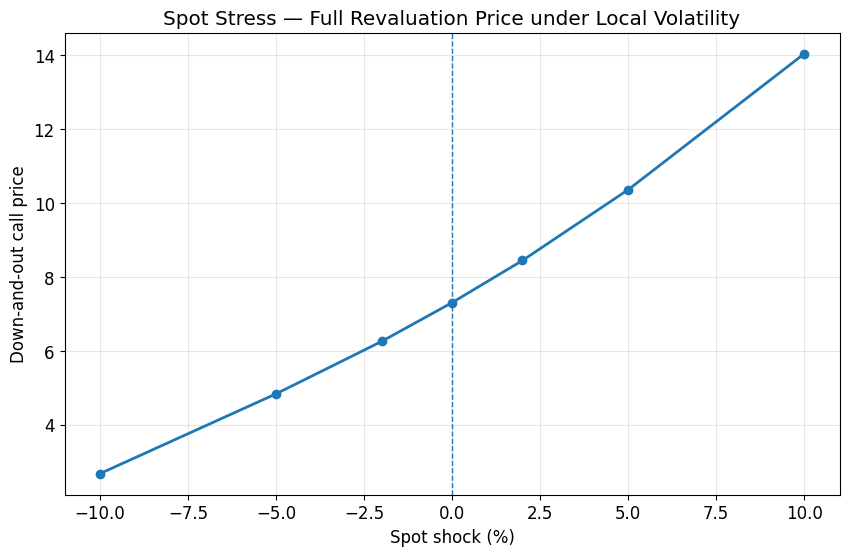

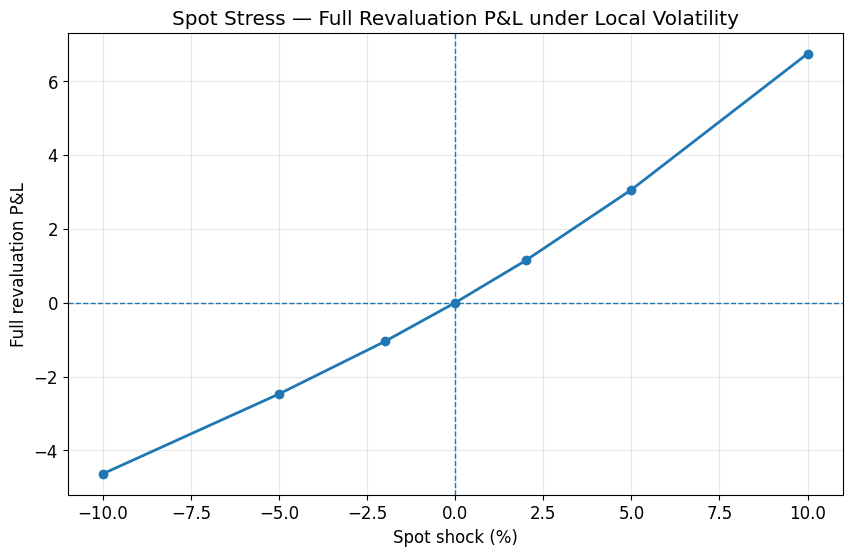

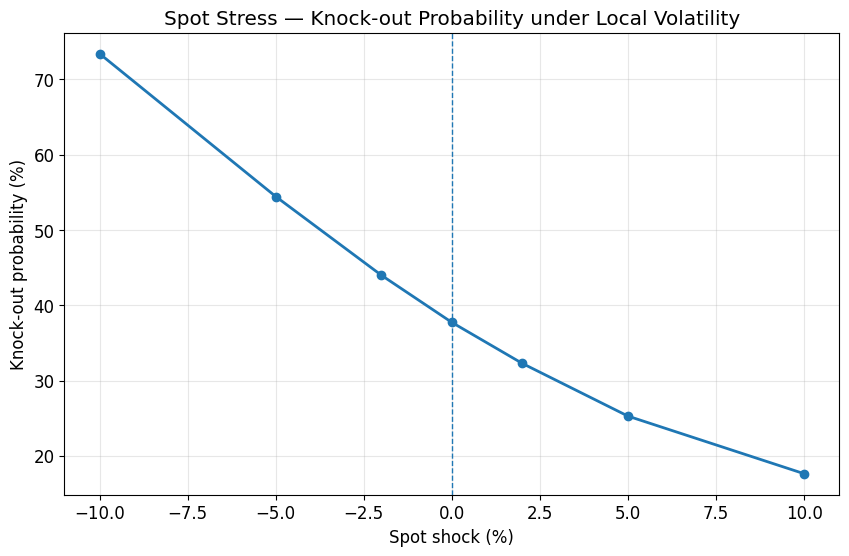

In [34]:
# =============================================================
# RISK MONITORING — Spot stress visualisation
# =============================================================

spot_shocks_percent = np.array([
    100.0 * row["spot_shock"]
    for row in spot_stress_results
])

spot_stress_prices = np.array([
    row["price"]
    for row in spot_stress_results
])

spot_stress_pnl = np.array([
    row["full_revaluation_pnl"]
    for row in spot_stress_results
])

spot_stress_knock_out_probabilities = np.array([
    row["knock_out_probability"]
    for row in spot_stress_results
])


# Graphique 1 — Prix du DOC selon le choc de spot
plt.figure(figsize=(10, 6))
plt.plot(spot_shocks_percent, spot_stress_prices, marker="o", linewidth=2)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot shock (%)")
plt.ylabel("Down-and-out call price")
plt.title("Spot Stress — Full Revaluation Price under Local Volatility")
plt.grid(True)
plt.show()


# Graphique 2 — P&L full revaluation selon le choc de spot
plt.figure(figsize=(10, 6))
plt.plot(spot_shocks_percent, spot_stress_pnl, marker="o", linewidth=2)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot shock (%)")
plt.ylabel("Full revaluation P&L")
plt.title("Spot Stress — Full Revaluation P&L under Local Volatility")
plt.grid(True)
plt.show()


# Graphique 3 — Probabilité de knock-out selon le choc de spot
plt.figure(figsize=(10, 6))
plt.plot(
    spot_shocks_percent,
    100.0 * spot_stress_knock_out_probabilities,
    marker="o",
    linewidth=2
)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot shock (%)")
plt.ylabel("Knock-out probability (%)")
plt.title("Spot Stress — Knock-out Probability under Local Volatility")
plt.grid(True)
plt.show()

In [35]:
# =============================================================
# RISK MONITORING — Delta-Gamma P&L attribution
# =============================================================

DELTA_GAMMA_BUMP = 1.0

# Full revaluation around the reference spot.
# The same Monte Carlo seed is used to reduce noise in finite differences.
price_spot_up = price_down_and_out_call_full_revaluation(
    spot=RISK_SPOT + DELTA_GAMMA_BUMP,
    strike=RISK_STRIKE,
    maturity=RISK_MATURITY,
    barrier=RISK_BARRIER,
    volatility_function=_original_flv,
    n_paths=RISK_N_PATHS,
    n_steps=RISK_N_STEPS,
    seed=RISK_SEED
)["price"]

price_spot_mid = local_vol_snapshot["price"]

price_spot_down = price_down_and_out_call_full_revaluation(
    spot=RISK_SPOT - DELTA_GAMMA_BUMP,
    strike=RISK_STRIKE,
    maturity=RISK_MATURITY,
    barrier=RISK_BARRIER,
    volatility_function=_original_flv,
    n_paths=RISK_N_PATHS,
    n_steps=RISK_N_STEPS,
    seed=RISK_SEED
)["price"]

risk_delta = (price_spot_up - price_spot_down) / (2.0 * DELTA_GAMMA_BUMP)

risk_gamma = (
    price_spot_up
    - 2.0 * price_spot_mid
    + price_spot_down
) / (DELTA_GAMMA_BUMP ** 2)


pnl_attribution_results = []

for row in spot_stress_results:
    spot_move = row["stressed_spot"] - RISK_SPOT

    delta_pnl = risk_delta * spot_move
    gamma_pnl = 0.5 * risk_gamma * spot_move ** 2
    delta_gamma_pnl = delta_pnl + gamma_pnl

    residual_pnl = row["full_revaluation_pnl"] - delta_gamma_pnl

    pnl_attribution_results.append({
        "spot_shock": row["spot_shock"],
        "spot_move": spot_move,
        "full_revaluation_pnl": row["full_revaluation_pnl"],
        "delta_pnl": delta_pnl,
        "gamma_pnl": gamma_pnl,
        "delta_gamma_pnl": delta_gamma_pnl,
        "residual_pnl": residual_pnl
    })


print("Delta-Gamma P&L Attribution")
print("===========================")
print()
print(f"Delta bump used : {DELTA_GAMMA_BUMP:.2f}")
print(f"Local delta     : {risk_delta:.4f}")
print(f"Local gamma     : {risk_gamma:.4f}")
print()
print(
    f"{'Shock':>8} | "
    f"{'dS':>8} | "
    f"{'Full P&L':>10} | "
    f"{'Delta P&L':>10} | "
    f"{'Gamma P&L':>10} | "
    f"{'DG Approx':>10} | "
    f"{'Residual':>10}"
)
print("-" * 92)

for row in pnl_attribution_results:
    print(
        f"{row['spot_shock']:>+8.0%} | "
        f"{row['spot_move']:>8.2f} | "
        f"{row['full_revaluation_pnl']:>+10.4f} | "
        f"{row['delta_pnl']:>+10.4f} | "
        f"{row['gamma_pnl']:>+10.4f} | "
        f"{row['delta_gamma_pnl']:>+10.4f} | "
        f"{row['residual_pnl']:>+10.4f}"
    )

Delta-Gamma P&L Attribution

Delta bump used : 1.00
Local delta     : 0.5521
Local gamma     : 0.0183

   Shock |       dS |   Full P&L |  Delta P&L |  Gamma P&L |  DG Approx |   Residual
--------------------------------------------------------------------------------------------
    -10% |   -10.00 |    -4.6305 |    -5.5209 |    +0.9148 |    -4.6061 |    -0.0245
     -5% |    -5.00 |    -2.4702 |    -2.7604 |    +0.2287 |    -2.5317 |    +0.0616
     -2% |    -2.00 |    -1.0506 |    -1.1042 |    +0.0366 |    -1.0676 |    +0.0170
     +0% |     0.00 |    +0.0000 |    +0.0000 |    +0.0000 |    +0.0000 |    +0.0000
     +2% |     2.00 |    +1.1413 |    +1.1042 |    +0.0366 |    +1.1408 |    +0.0005
     +5% |     5.00 |    +3.0562 |    +2.7604 |    +0.2287 |    +2.9891 |    +0.0671
    +10% |    10.00 |    +6.7371 |    +5.5209 |    +0.9148 |    +6.4357 |    +0.3014


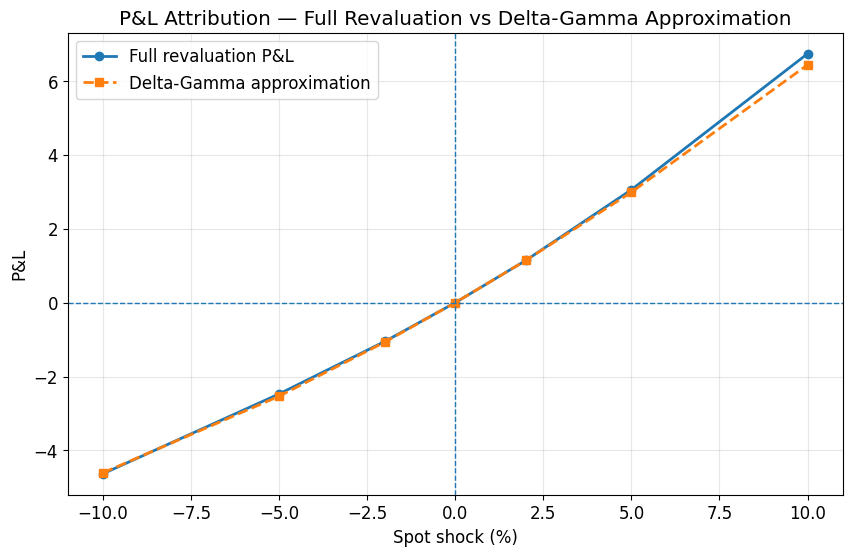

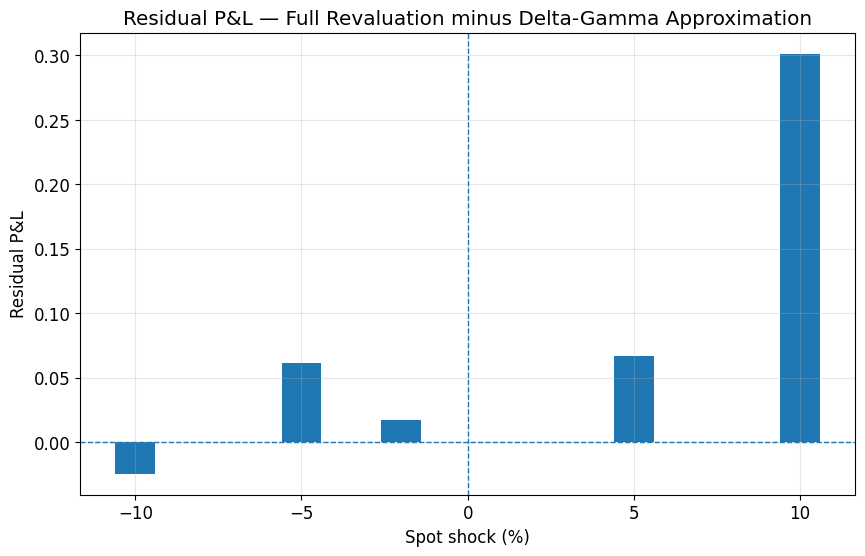

In [36]:
# =============================================================
# RISK MONITORING — Delta-Gamma attribution visualisation
# =============================================================

pnl_attribution_shocks_percent = np.array([
    100.0 * row["spot_shock"]
    for row in pnl_attribution_results
])

full_revaluation_pnl_values = np.array([
    row["full_revaluation_pnl"]
    for row in pnl_attribution_results
])

delta_gamma_pnl_values = np.array([
    row["delta_gamma_pnl"]
    for row in pnl_attribution_results
])

residual_pnl_values = np.array([
    row["residual_pnl"]
    for row in pnl_attribution_results
])


# Graphique 1 — Full revaluation P&L vs Delta-Gamma approximation
plt.figure(figsize=(10, 6))
plt.plot(
    pnl_attribution_shocks_percent,
    full_revaluation_pnl_values,
    marker="o",
    linewidth=2,
    label="Full revaluation P&L"
)
plt.plot(
    pnl_attribution_shocks_percent,
    delta_gamma_pnl_values,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Delta-Gamma approximation"
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot shock (%)")
plt.ylabel("P&L")
plt.title("P&L Attribution — Full Revaluation vs Delta-Gamma Approximation")
plt.legend()
plt.grid(True)
plt.show()


# Graphique 2 — Residual P&L
plt.figure(figsize=(10, 6))
plt.bar(
    pnl_attribution_shocks_percent,
    residual_pnl_values,
    width=1.2
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot shock (%)")
plt.ylabel("Residual P&L")
plt.title("Residual P&L — Full Revaluation minus Delta-Gamma Approximation")
plt.grid(True)
plt.show()

In [37]:
# =============================================================
# RISK MONITORING — Barrier stress
# =============================================================

BARRIER_STRESS_LEVELS = np.array([75, 80, 85, 90, 95])

barrier_stress_results = []

base_barrier_price = local_vol_snapshot["price"]

for stressed_barrier in BARRIER_STRESS_LEVELS:
    stressed_barrier_snapshot = price_down_and_out_call_full_revaluation(
        spot=RISK_SPOT,
        strike=RISK_STRIKE,
        maturity=RISK_MATURITY,
        barrier=stressed_barrier,
        volatility_function=_original_flv,
        n_paths=RISK_N_PATHS,
        n_steps=RISK_N_STEPS,
        seed=RISK_SEED
    )

    barrier_pnl = stressed_barrier_snapshot["price"] - base_barrier_price

    barrier_stress_results.append({
        "barrier": stressed_barrier,
        "price": stressed_barrier_snapshot["price"],
        "standard_error": stressed_barrier_snapshot["standard_error"],
        "pnl_vs_base_barrier": barrier_pnl,
        "knock_out_probability": stressed_barrier_snapshot["knock_out_probability"],
        "survival_probability": stressed_barrier_snapshot["survival_probability"]
    })


print("Barrier Stress — Full Revaluation under Local Volatility")
print("========================================================")
print()
print(
    f"{'Barrier':>8} | "
    f"{'Price':>10} | "
    f"{'Std Error':>10} | "
    f"{'P&L vs B=85':>12} | "
    f"{'KO Prob.':>10} | "
    f"{'Survival':>10}"
)
print("-" * 86)

for row in barrier_stress_results:
    print(
        f"{row['barrier']:>8.2f} | "
        f"{row['price']:>10.4f} | "
        f"{row['standard_error']:>10.4f} | "
        f"{row['pnl_vs_base_barrier']:>+12.4f} | "
        f"{row['knock_out_probability']:>10.2%} | "
        f"{row['survival_probability']:>10.2%}"
    )

Barrier Stress — Full Revaluation under Local Volatility

 Barrier |      Price |  Std Error |  P&L vs B=85 |   KO Prob. |   Survival
--------------------------------------------------------------------------------------
   75.00 |     7.7521 |     0.0756 |      +0.4451 |     18.97% |     81.03%
   80.00 |     7.6218 |     0.0755 |      +0.3148 |     26.49% |     73.51%
   85.00 |     7.3071 |     0.0752 |      +0.0000 |     37.72% |     62.28%
   90.00 |     6.5243 |     0.0741 |      -0.7827 |     54.08% |     45.92%
   95.00 |     4.6744 |     0.0686 |      -2.6327 |     75.47% |     24.53%


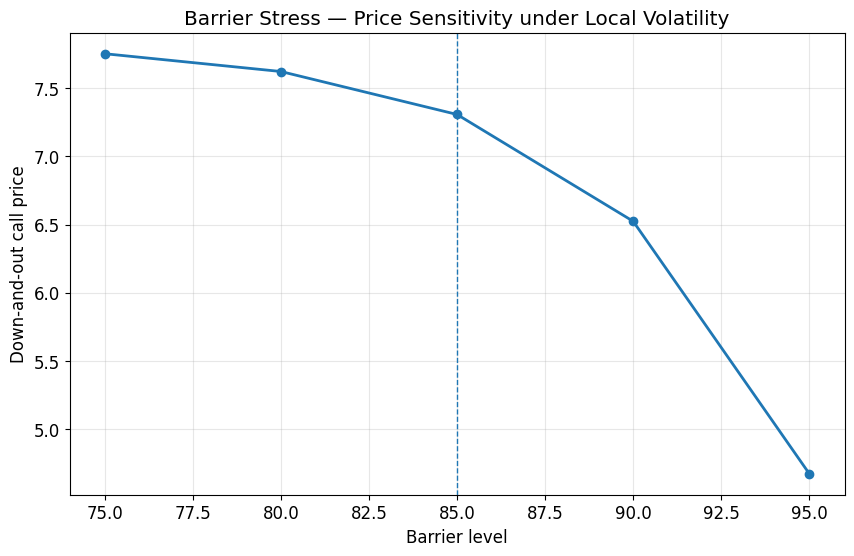

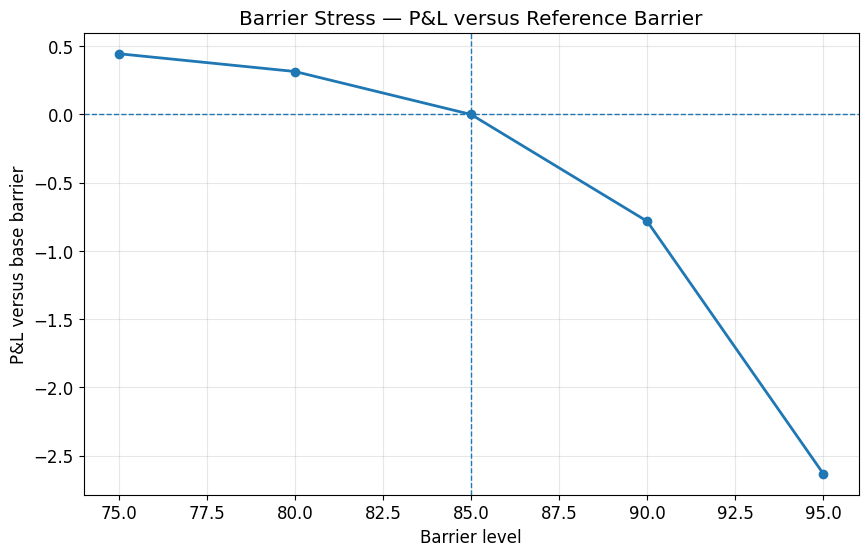

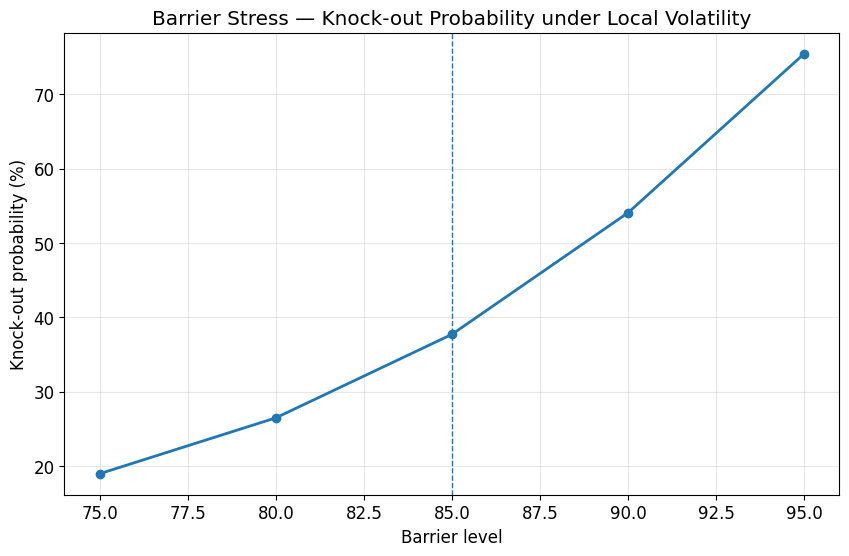

In [38]:
# =============================================================
# RISK MONITORING — Barrier stress visualisation
# =============================================================

barrier_levels = np.array([
    row["barrier"]
    for row in barrier_stress_results
])

barrier_prices = np.array([
    row["price"]
    for row in barrier_stress_results
])

barrier_pnl_values = np.array([
    row["pnl_vs_base_barrier"]
    for row in barrier_stress_results
])

barrier_knock_out_probabilities = np.array([
    row["knock_out_probability"]
    for row in barrier_stress_results
])


# Graphique 1 — Prix selon le niveau de barrière
plt.figure(figsize=(10, 6))
plt.plot(barrier_levels, barrier_prices, marker="o", linewidth=2)
plt.axvline(RISK_BARRIER, linestyle="--", linewidth=1)
plt.xlabel("Barrier level")
plt.ylabel("Down-and-out call price")
plt.title("Barrier Stress — Price Sensitivity under Local Volatility")
plt.grid(True)
plt.show()


# Graphique 2 — P&L selon le niveau de barrière
plt.figure(figsize=(10, 6))
plt.plot(barrier_levels, barrier_pnl_values, marker="o", linewidth=2)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(RISK_BARRIER, linestyle="--", linewidth=1)
plt.xlabel("Barrier level")
plt.ylabel("P&L versus base barrier")
plt.title("Barrier Stress — P&L versus Reference Barrier")
plt.grid(True)
plt.show()


# Graphique 3 — Probabilité de knock-out selon la barrière
plt.figure(figsize=(10, 6))
plt.plot(
    barrier_levels,
    100.0 * barrier_knock_out_probabilities,
    marker="o",
    linewidth=2
)
plt.axvline(RISK_BARRIER, linestyle="--", linewidth=1)
plt.xlabel("Barrier level")
plt.ylabel("Knock-out probability (%)")
plt.title("Barrier Stress — Knock-out Probability under Local Volatility")
plt.grid(True)
plt.show()

### Risk Monitoring Interpretation

The risk monitoring layer highlights three key dimensions of the down-and-out call.

First, the local volatility model produces a lower mark-to-model value than the Black-Scholes flat-volatility benchmark. The model difference is around three percent of the option value and is larger than the combined Monte Carlo noise level. This confirms that the pricing gap is not only a numerical artifact, but a meaningful model-risk effect.

Second, the spot stress analysis shows the strong path-dependence of the product. When the spot moves closer to the barrier, the option value drops sharply and the knock-out probability increases materially. In the base case, the knock-out probability is already significant, and it rises strongly under downside spot shocks.

Third, the Delta-Gamma attribution explains most of the full revaluation P&L over the tested spot shock range. This indicates that first- and second-order spot sensitivities provide a useful local approximation around the reference spot. However, the residual P&L increases for larger shocks, especially when the option moves further away from the local expansion point.

Finally, the barrier stress analysis confirms that the barrier level is a key structural driver of the product value. Moving the barrier closer to the spot increases the knock-out probability and reduces the option price significantly. This should be interpreted as a structural sensitivity or product-design stress, not as a daily market P&L, since the barrier is contractually fixed once the trade is issued.

Overall, this section turns the pricing notebook into a desk-oriented diagnostic tool: it combines mark-to-model valuation, model-risk comparison, spot stress testing, Delta-Gamma P&L attribution, and knock-out probability monitoring.

## 2 bis. Market Data Simulation & Implied Volatility Reconstruction

Until now, the notebook assumes that a clean implied volatility surface is directly available.

In practice, a quant analyst usually starts from option quotes: strikes, maturities, bid prices, ask prices, mid prices and liquidity indicators. The implied volatility surface must then be reconstructed from these quotes.

This section adds a market-data-like layer:

- generation of a synthetic option chain from the SVI surface;
- bid/ask spread simulation;
- quote noise;
- volume and liquidity simulation;
- cleaning of unreliable quotes;
- implied volatility reconstruction from mid prices.

The data remains synthetic, but the workflow is closer to a realistic market data pipeline.

In [39]:
# =============================================================
# MARKET DATA SIMULATION — Configuration
# =============================================================

MARKET_DATA_SEED = 123
market_data_rng = np.random.default_rng(MARKET_DATA_SEED)

# We reuse the existing SVI grid.
MARKET_DATA_SPOT = S0
MARKET_DATA_STRIKES = strikes
MARKET_DATA_MATURITY_LABELS = list(svi_params.keys())
MARKET_DATA_MATURITIES = np.array([
    maturities_days[label] / 365
    for label in MARKET_DATA_MATURITY_LABELS
])

# Quote simulation parameters.
# The spread is wider for far OTM options and for lower theoretical prices.
MARKET_DATA_MIN_ABSOLUTE_SPREAD = 0.01
MARKET_DATA_RELATIVE_SPREAD = 0.03
MARKET_DATA_WING_SPREAD_MULTIPLIER = 0.40

# Mid quote noise is expressed as a fraction of the simulated bid/ask spread.
MARKET_DATA_MID_NOISE_FRACTION = 0.15

# Liquidity model parameters.
MARKET_DATA_BASE_VOLUME = 1_000
MARKET_DATA_MIN_VOLUME = 1
MARKET_DATA_VOLUME_NOISE_STD = 0.25

print("Market Data Simulation configuration")
print("------------------------------------")
print(f"Seed                      : {MARKET_DATA_SEED}")
print(f"Spot                      : {MARKET_DATA_SPOT}")
print(f"Number of strikes         : {len(MARKET_DATA_STRIKES)}")
print(f"Number of maturities      : {len(MARKET_DATA_MATURITIES)}")
print(f"Total raw quote candidates: {len(MARKET_DATA_STRIKES) * len(MARKET_DATA_MATURITIES)}")
print(f"Min absolute spread       : {MARKET_DATA_MIN_ABSOLUTE_SPREAD:.4f}")
print(f"Relative spread           : {MARKET_DATA_RELATIVE_SPREAD:.2%}")
print(f"Mid noise fraction        : {MARKET_DATA_MID_NOISE_FRACTION:.2%}")

Market Data Simulation configuration
------------------------------------
Seed                      : 123
Spot                      : 100
Number of strikes         : 61
Number of maturities      : 5
Total raw quote candidates: 305
Min absolute spread       : 0.0100
Relative spread           : 3.00%
Mid noise fraction        : 15.00%


In [40]:
# =============================================================
# MARKET DATA SIMULATION — Atomic quote helpers
# =============================================================

def select_otm_option_type(strike, forward):
    """
    Selects the most liquid option type under the usual OTM convention.

    For strikes below the forward, puts are usually more liquid.
    For strikes above the forward, calls are usually more liquid.
    """
    if strike < forward:
        return "put"
    return "call"


def black_scholes_price_by_type(spot, strike, maturity, rate, dividend_yield, volatility, option_type):
    """
    Black-Scholes price for either a call or a put.
    """
    if option_type == "call":
        return bs_call_price(spot, strike, maturity, rate, dividend_yield, volatility)
    if option_type == "put":
        return bs_put_price(spot, strike, maturity, rate, dividend_yield, volatility)

    raise ValueError("option_type must be either 'call' or 'put'.")


def option_no_arbitrage_bounds(spot, strike, maturity, rate, dividend_yield, option_type):
    """
    Basic no-arbitrage lower and upper bounds for European options.
    """
    discounted_spot = spot * np.exp(-dividend_yield * maturity)
    discounted_strike = strike * np.exp(-rate * maturity)

    if option_type == "call":
        lower_bound = max(discounted_spot - discounted_strike, 0.0)
        upper_bound = discounted_spot
    elif option_type == "put":
        lower_bound = max(discounted_strike - discounted_spot, 0.0)
        upper_bound = discounted_strike
    else:
        raise ValueError("option_type must be either 'call' or 'put'.")

    return lower_bound, upper_bound


def simulate_bid_ask_quote(
    theoretical_price,
    lower_bound,
    upper_bound,
    log_forward_moneyness,
    rng
):
    """
    Simulates a noisy bid/ask quote around a theoretical option price.

    The spread increases in the wings, which mimics lower liquidity for far OTM options.
    The noisy mid is clipped inside basic no-arbitrage bounds.
    """
    wing_intensity = abs(log_forward_moneyness)

    absolute_spread = (
        MARKET_DATA_MIN_ABSOLUTE_SPREAD
        + MARKET_DATA_RELATIVE_SPREAD * theoretical_price
        + MARKET_DATA_WING_SPREAD_MULTIPLIER * wing_intensity * MARKET_DATA_MIN_ABSOLUTE_SPREAD
    )

    mid_noise = rng.normal(
        loc=0.0,
        scale=MARKET_DATA_MID_NOISE_FRACTION * absolute_spread
    )

    raw_mid_price = theoretical_price + mid_noise

    epsilon = 1e-8
    clipped_mid_price = np.clip(
        raw_mid_price,
        lower_bound + epsilon,
        upper_bound - epsilon
    )

    bid_price = max(clipped_mid_price - 0.5 * absolute_spread, 0.0)
    ask_price = clipped_mid_price + 0.5 * absolute_spread

    # Safety clipping: ask must remain below the theoretical upper bound.
    ask_price = min(ask_price, upper_bound)

    if ask_price <= bid_price:
        ask_price = bid_price + MARKET_DATA_MIN_ABSOLUTE_SPREAD

    mid_price = 0.5 * (bid_price + ask_price)

    return bid_price, ask_price, mid_price, absolute_spread


def simulate_quote_volume(log_forward_moneyness, maturity, rng):
    """
    Simulates a simple liquidity proxy.

    Volume decreases when the option is far from ATM and for longer maturities.
    A lognormal random component avoids a fully deterministic volume curve.
    """
    distance_penalty = np.exp(-8.0 * abs(log_forward_moneyness))
    maturity_penalty = np.exp(-0.20 * maturity)
    random_liquidity_multiplier = rng.lognormal(
        mean=0.0,
        sigma=MARKET_DATA_VOLUME_NOISE_STD
    )

    volume = (
        MARKET_DATA_BASE_VOLUME
        * distance_penalty
        * maturity_penalty
        * random_liquidity_multiplier
    )

    return int(max(MARKET_DATA_MIN_VOLUME, round(volume)))

In [41]:
# =============================================================
# MARKET DATA SIMULATION — Synthetic option chain generation
# =============================================================

simulated_option_chain = []

quote_id = 0

for maturity_label, maturity in zip(MARKET_DATA_MATURITY_LABELS, MARKET_DATA_MATURITIES):
    forward = MARKET_DATA_SPOT * np.exp((r - q) * maturity)

    for strike in MARKET_DATA_STRIKES:
        log_forward_moneyness = np.log(strike / forward)

        option_type = select_otm_option_type(
            strike=strike,
            forward=forward
        )

        true_implied_volatility = surface.implied_vol(
            K=strike,
            T=maturity
        )

        theoretical_price = black_scholes_price_by_type(
            spot=MARKET_DATA_SPOT,
            strike=strike,
            maturity=maturity,
            rate=r,
            dividend_yield=q,
            volatility=true_implied_volatility,
            option_type=option_type
        )

        lower_bound, upper_bound = option_no_arbitrage_bounds(
            spot=MARKET_DATA_SPOT,
            strike=strike,
            maturity=maturity,
            rate=r,
            dividend_yield=q,
            option_type=option_type
        )

        bid_price, ask_price, mid_price, bid_ask_spread = simulate_bid_ask_quote(
            theoretical_price=theoretical_price,
            lower_bound=lower_bound,
            upper_bound=upper_bound,
            log_forward_moneyness=log_forward_moneyness,
            rng=market_data_rng
        )

        volume = simulate_quote_volume(
            log_forward_moneyness=log_forward_moneyness,
            maturity=maturity,
            rng=market_data_rng
        )

        simulated_option_chain.append({
            "quote_id": quote_id,
            "maturity_label": maturity_label,
            "maturity": maturity,
            "forward": forward,
            "strike": strike,
            "log_forward_moneyness": log_forward_moneyness,
            "option_type": option_type,
            "true_implied_volatility": true_implied_volatility,
            "theoretical_price": theoretical_price,
            "bid_price": bid_price,
            "ask_price": ask_price,
            "mid_price": mid_price,
            "bid_ask_spread": bid_ask_spread,
            "relative_spread": bid_ask_spread / max(mid_price, 1e-8),
            "volume": volume
        })

        quote_id += 1


print("Synthetic option chain generated")
print("--------------------------------")
print(f"Number of simulated quotes : {len(simulated_option_chain)}")
print()

print("First 10 simulated quotes")
print("-------------------------")
print(
    f"{'ID':>4} | "
    f"{'Mat':>4} | "
    f"{'Type':>4} | "
    f"{'Strike':>8} | "
    f"{'True IV':>8} | "
    f"{'Theo':>9} | "
    f"{'Bid':>9} | "
    f"{'Ask':>9} | "
    f"{'Mid':>9} | "
    f"{'Volume':>8}"
)
print("-" * 100)

for row in simulated_option_chain[:10]:
    print(
        f"{row['quote_id']:>4} | "
        f"{row['maturity_label']:>4} | "
        f"{row['option_type']:>4} | "
        f"{row['strike']:>8.2f} | "
        f"{row['true_implied_volatility']:>8.2%} | "
        f"{row['theoretical_price']:>9.4f} | "
        f"{row['bid_price']:>9.4f} | "
        f"{row['ask_price']:>9.4f} | "
        f"{row['mid_price']:>9.4f} | "
        f"{row['volume']:>8}"
    )

Synthetic option chain generated
--------------------------------
Number of simulated quotes : 305

First 10 simulated quotes
-------------------------
  ID |  Mat | Type |   Strike |  True IV |      Theo |       Bid |       Ask |       Mid |   Volume
----------------------------------------------------------------------------------------------------
   0 |   1M |  put |    70.00 |   74.11% |    0.3369 |    0.3230 |    0.3445 |    0.3337 |       51
   1 |   1M |  put |    71.00 |   72.83% |    0.3658 |    0.3589 |    0.3813 |    0.3701 |       66
   2 |   1M |  put |    72.00 |   71.55% |    0.3969 |    0.3885 |    0.4117 |    0.4001 |       82
   3 |   1M |  put |    73.00 |   70.26% |    0.4303 |    0.4159 |    0.4401 |    0.4280 |       90
   4 |   1M |  put |    74.00 |   68.98% |    0.4663 |    0.4525 |    0.4777 |    0.4651 |       81
   5 |   1M |  put |    75.00 |   67.69% |    0.5049 |    0.4922 |    0.5185 |    0.5053 |       67
   6 |   1M |  put |    76.00 |   66.40% |    0

In [42]:
# =============================================================
# MARKET DATA SIMULATION — Quote cleaning configuration
# =============================================================

# Tighter filters to make the cleaning step economically meaningful.
# Quotes with very wide bid/ask spreads or very low volume are removed.
MARKET_DATA_MAX_RELATIVE_SPREAD = 0.075
MARKET_DATA_MIN_CLEAN_VOLUME = 50

print("Quote cleaning configuration")
print("----------------------------")
print(f"Max relative spread : {MARKET_DATA_MAX_RELATIVE_SPREAD:.2%}")
print(f"Minimum volume      : {MARKET_DATA_MIN_CLEAN_VOLUME}")

Quote cleaning configuration
----------------------------
Max relative spread : 7.50%
Minimum volume      : 50


In [43]:
# =============================================================
# MARKET DATA SIMULATION — Quote validation helper
# =============================================================

def is_valid_option_quote(quote):
    """
    Checks whether a simulated option quote is usable for implied volatility reconstruction.

    The filters mimic basic market-data cleaning rules:
    - strictly positive bid;
    - ask above bid;
    - mid price inside no-arbitrage bounds;
    - acceptable relative bid/ask spread;
    - sufficient volume.
    """
    lower_bound, upper_bound = option_no_arbitrage_bounds(
        spot=MARKET_DATA_SPOT,
        strike=quote["strike"],
        maturity=quote["maturity"],
        rate=r,
        dividend_yield=q,
        option_type=quote["option_type"]
    )

    has_positive_bid = quote["bid_price"] > 0.0
    has_valid_bid_ask = quote["ask_price"] > quote["bid_price"]
    has_valid_mid_price = lower_bound < quote["mid_price"] < upper_bound
    has_reasonable_spread = quote["relative_spread"] <= MARKET_DATA_MAX_RELATIVE_SPREAD
    has_sufficient_volume = quote["volume"] >= MARKET_DATA_MIN_CLEAN_VOLUME

    return (
        has_positive_bid
        and has_valid_bid_ask
        and has_valid_mid_price
        and has_reasonable_spread
        and has_sufficient_volume
    )

In [44]:
# =============================================================
# MARKET DATA SIMULATION — Quote cleaning
# =============================================================

clean_option_chain = []
rejected_option_chain = []

for quote in simulated_option_chain:
    if is_valid_option_quote(quote):
        clean_option_chain.append(quote)
    else:
        rejected_option_chain.append(quote)


number_of_raw_quotes = len(simulated_option_chain)
number_of_clean_quotes = len(clean_option_chain)
number_of_rejected_quotes = len(rejected_option_chain)

cleaning_retention_rate = number_of_clean_quotes / number_of_raw_quotes

print("Quote Cleaning Summary")
print("======================")
print()
print(f"Raw quotes       : {number_of_raw_quotes}")
print(f"Clean quotes     : {number_of_clean_quotes}")
print(f"Rejected quotes  : {number_of_rejected_quotes}")
print(f"Retention rate   : {cleaning_retention_rate:.2%}")
print()

print("Clean quotes by maturity")
print("------------------------")

for maturity_label in MARKET_DATA_MATURITY_LABELS:
    raw_count = sum(
        quote["maturity_label"] == maturity_label
        for quote in simulated_option_chain
    )

    clean_count = sum(
        quote["maturity_label"] == maturity_label
        for quote in clean_option_chain
    )

    print(
        f"{maturity_label:>4} : "
        f"{clean_count:>3} / {raw_count:<3} clean quotes "
        f"({clean_count / raw_count:.2%})"
    )

Quote Cleaning Summary

Raw quotes       : 305
Clean quotes     : 291
Rejected quotes  : 14
Retention rate   : 95.41%

Clean quotes by maturity
------------------------
  1M :  56 / 61  clean quotes (91.80%)
  3M :  61 / 61  clean quotes (100.00%)
  6M :  60 / 61  clean quotes (98.36%)
  1Y :  59 / 61  clean quotes (96.72%)
  2Y :  55 / 61  clean quotes (90.16%)


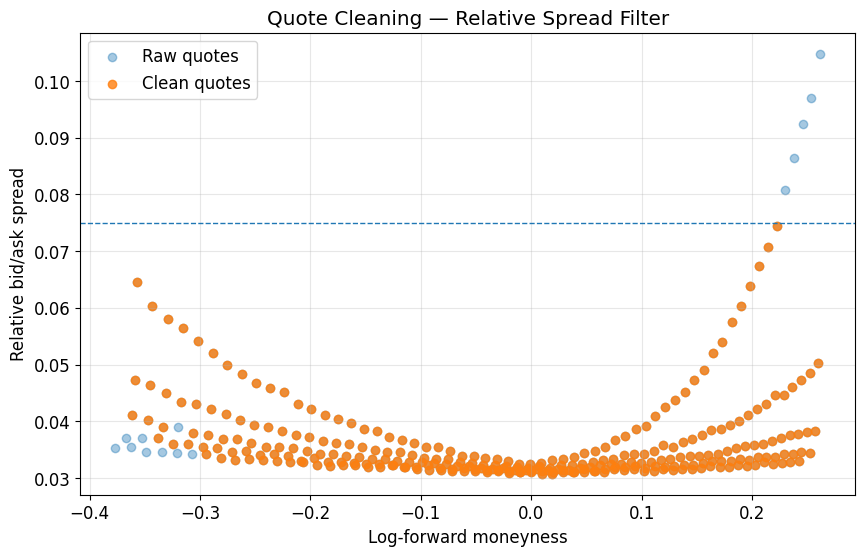

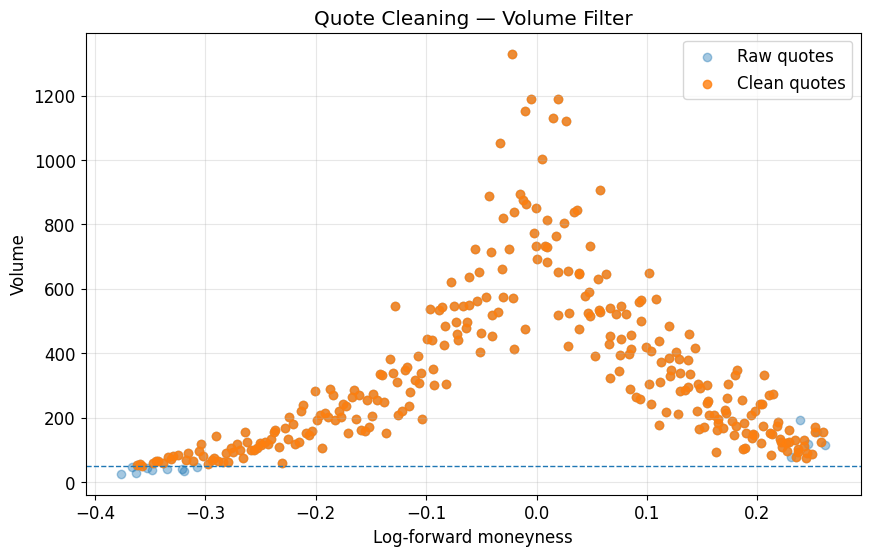

In [45]:
# =============================================================
# MARKET DATA SIMULATION — Quote cleaning visualisation
# =============================================================

raw_log_moneyness = np.array([
    quote["log_forward_moneyness"]
    for quote in simulated_option_chain
])

raw_relative_spreads = np.array([
    quote["relative_spread"]
    for quote in simulated_option_chain
])

raw_volumes = np.array([
    quote["volume"]
    for quote in simulated_option_chain
])

clean_log_moneyness = np.array([
    quote["log_forward_moneyness"]
    for quote in clean_option_chain
])

clean_relative_spreads = np.array([
    quote["relative_spread"]
    for quote in clean_option_chain
])

clean_volumes = np.array([
    quote["volume"]
    for quote in clean_option_chain
])


# Graphique 1 — Relative spread before and after cleaning
plt.figure(figsize=(10, 6))
plt.scatter(raw_log_moneyness, raw_relative_spreads, alpha=0.4, label="Raw quotes")
plt.scatter(clean_log_moneyness, clean_relative_spreads, alpha=0.8, label="Clean quotes")
plt.axhline(MARKET_DATA_MAX_RELATIVE_SPREAD, linestyle="--", linewidth=1)
plt.xlabel("Log-forward moneyness")
plt.ylabel("Relative bid/ask spread")
plt.title("Quote Cleaning — Relative Spread Filter")
plt.legend()
plt.grid(True)
plt.show()


# Graphique 2 — Volume before and after cleaning
plt.figure(figsize=(10, 6))
plt.scatter(raw_log_moneyness, raw_volumes, alpha=0.4, label="Raw quotes")
plt.scatter(clean_log_moneyness, clean_volumes, alpha=0.8, label="Clean quotes")
plt.axhline(MARKET_DATA_MIN_CLEAN_VOLUME, linestyle="--", linewidth=1)
plt.xlabel("Log-forward moneyness")
plt.ylabel("Volume")
plt.title("Quote Cleaning — Volume Filter")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# =============================================================
# MARKET DATA SIMULATION — Implied volatility reconstruction
# =============================================================

def reconstruct_implied_volatility_from_mid_price(quote):
    """
    Reconstructs the Black-Scholes implied volatility from a cleaned mid price.

    The function uses the same option type as the quote and solves:
        BS_price(volatility) = mid_price

    Returns np.nan if the inversion fails.
    """
    def pricing_error(volatility):
        model_price = black_scholes_price_by_type(
            spot=MARKET_DATA_SPOT,
            strike=quote["strike"],
            maturity=quote["maturity"],
            rate=r,
            dividend_yield=q,
            volatility=volatility,
            option_type=quote["option_type"]
        )

        return model_price - quote["mid_price"]

    try:
        implied_volatility = brentq(
            pricing_error,
            1e-4,
            5.0,
            xtol=1e-12
        )

        return implied_volatility

    except ValueError:
        return np.nan


reconstructed_option_chain = []

for quote in clean_option_chain:
    reconstructed_implied_volatility = reconstruct_implied_volatility_from_mid_price(quote)

    if not np.isnan(reconstructed_implied_volatility):
        reconstructed_quote = quote.copy()
        reconstructed_quote["reconstructed_implied_volatility"] = reconstructed_implied_volatility
        reconstructed_quote["iv_error"] = (
            reconstructed_implied_volatility
            - reconstructed_quote["true_implied_volatility"]
        )
        reconstructed_quote["absolute_iv_error"] = abs(reconstructed_quote["iv_error"])

        reconstructed_option_chain.append(reconstructed_quote)


print("Implied Volatility Reconstruction Summary")
print("=========================================")
print()
print(f"Clean quotes available          : {len(clean_option_chain)}")
print(f"Successfully reconstructed IVs  : {len(reconstructed_option_chain)}")
print(f"Failed inversions               : {len(clean_option_chain) - len(reconstructed_option_chain)}")
print()

iv_errors = np.array([
    quote["iv_error"]
    for quote in reconstructed_option_chain
])

absolute_iv_errors = np.array([
    quote["absolute_iv_error"]
    for quote in reconstructed_option_chain
])

print("Reconstruction error")
print("--------------------")
print(f"Mean IV error       : {np.mean(iv_errors):+.4%}")
print(f"Mean absolute error : {np.mean(absolute_iv_errors):.4%}")
print(f"Max absolute error  : {np.max(absolute_iv_errors):.4%}")

Implied Volatility Reconstruction Summary

Clean quotes available          : 291
Successfully reconstructed IVs  : 291
Failed inversions               : 0

Reconstruction error
--------------------
Mean IV error       : +0.0061%
Mean absolute error : 0.0641%
Max absolute error  : 0.2860%


In [47]:
# =============================================================
# MARKET DATA SIMULATION — Reconstruction diagnostics by maturity
# =============================================================

print("Implied Volatility Reconstruction by Maturity")
print("============================================")
print()
print(
    f"{'Maturity':>8} | "
    f"{'Quotes':>6} | "
    f"{'Mean Error':>12} | "
    f"{'Mean Abs Error':>15} | "
    f"{'Max Abs Error':>13}"
)
print("-" * 68)

for maturity_label in MARKET_DATA_MATURITY_LABELS:
    maturity_quotes = [
        quote for quote in reconstructed_option_chain
        if quote["maturity_label"] == maturity_label
    ]

    maturity_errors = np.array([
        quote["iv_error"]
        for quote in maturity_quotes
    ])

    maturity_absolute_errors = np.array([
        quote["absolute_iv_error"]
        for quote in maturity_quotes
    ])

    print(
        f"{maturity_label:>8} | "
        f"{len(maturity_quotes):>6} | "
        f"{np.mean(maturity_errors):>+12.4%} | "
        f"{np.mean(maturity_absolute_errors):>15.4%} | "
        f"{np.max(maturity_absolute_errors):>13.4%}"
    )

Implied Volatility Reconstruction by Maturity

Maturity | Quotes |   Mean Error |  Mean Abs Error | Max Abs Error
--------------------------------------------------------------------
      1M |     56 |     +0.0263% |         0.0860% |       0.2860%
      3M |     61 |     +0.0037% |         0.0588% |       0.2301%
      6M |     60 |     +0.0019% |         0.0558% |       0.1798%
      1Y |     59 |     -0.0059% |         0.0641% |       0.2196%
      2Y |     55 |     +0.0059% |         0.0565% |       0.1949%


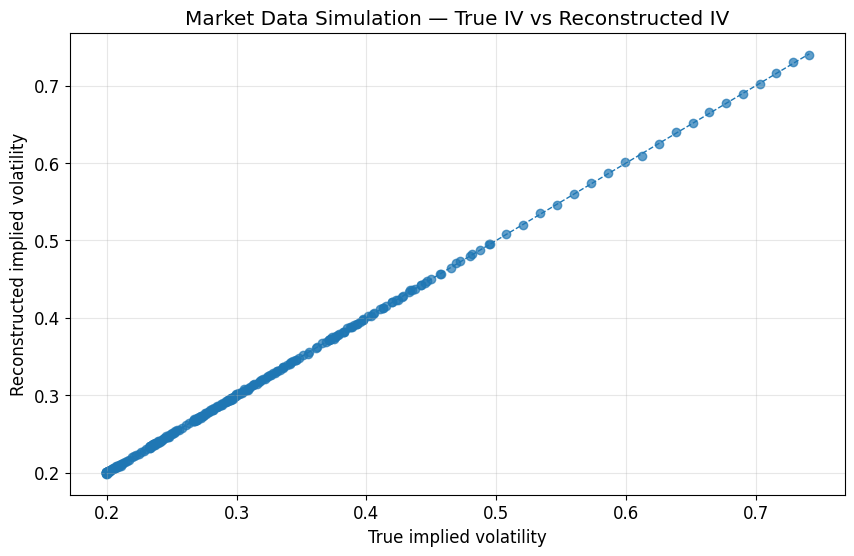

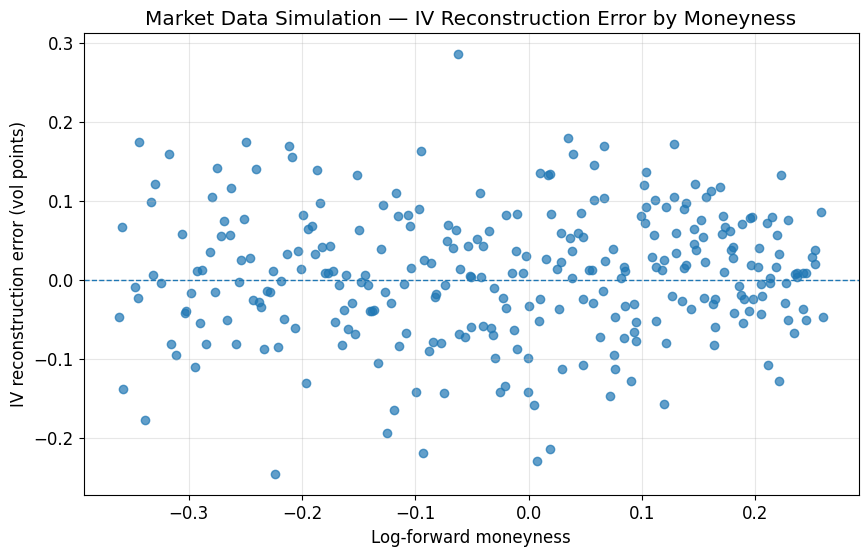

In [48]:
# =============================================================
# MARKET DATA SIMULATION — True IV vs reconstructed IV visualisation
# =============================================================

reconstructed_log_moneyness = np.array([
    quote["log_forward_moneyness"]
    for quote in reconstructed_option_chain
])

true_implied_volatilities = np.array([
    quote["true_implied_volatility"]
    for quote in reconstructed_option_chain
])

reconstructed_implied_volatilities = np.array([
    quote["reconstructed_implied_volatility"]
    for quote in reconstructed_option_chain
])

reconstruction_errors = np.array([
    quote["iv_error"]
    for quote in reconstructed_option_chain
])


# Graphique 1 — True IV vs reconstructed IV
plt.figure(figsize=(10, 6))
plt.scatter(
    true_implied_volatilities,
    reconstructed_implied_volatilities,
    alpha=0.7
)

min_volatility = min(
    np.min(true_implied_volatilities),
    np.min(reconstructed_implied_volatilities)
)

max_volatility = max(
    np.max(true_implied_volatilities),
    np.max(reconstructed_implied_volatilities)
)

plt.plot(
    [min_volatility, max_volatility],
    [min_volatility, max_volatility],
    linestyle="--",
    linewidth=1
)

plt.xlabel("True implied volatility")
plt.ylabel("Reconstructed implied volatility")
plt.title("Market Data Simulation — True IV vs Reconstructed IV")
plt.grid(True)
plt.show()


# Graphique 2 — IV reconstruction error by moneyness
plt.figure(figsize=(10, 6))
plt.scatter(
    reconstructed_log_moneyness,
    100.0 * reconstruction_errors,
    alpha=0.7
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Log-forward moneyness")
plt.ylabel("IV reconstruction error (vol points)")
plt.title("Market Data Simulation — IV Reconstruction Error by Moneyness")
plt.grid(True)
plt.show()

In [49]:
# =============================================================
# MARKET DATA SIMULATION — Reconstructed IV surface matrix
# =============================================================

# We rebuild a matrix on the original strike × maturity grid.
# Missing values (if any) are left as NaN.

reconstructed_iv_matrix = np.full(
    (len(MARKET_DATA_MATURITIES), len(MARKET_DATA_STRIKES)),
    np.nan
)

true_iv_matrix_on_clean_grid = np.full(
    (len(MARKET_DATA_MATURITIES), len(MARKET_DATA_STRIKES)),
    np.nan
)

maturity_index_map = {
    label: i
    for i, label in enumerate(MARKET_DATA_MATURITY_LABELS)
}

strike_index_map = {
    strike: j
    for j, strike in enumerate(MARKET_DATA_STRIKES)
}

for quote in reconstructed_option_chain:
    i = maturity_index_map[quote["maturity_label"]]
    j = strike_index_map[quote["strike"]]

    reconstructed_iv_matrix[i, j] = quote["reconstructed_implied_volatility"]
    true_iv_matrix_on_clean_grid[i, j] = quote["true_implied_volatility"]


print("Reconstructed IV surface matrix")
print("-------------------------------")
print(f"Shape : {reconstructed_iv_matrix.shape}")
print(f"Non-missing points : {np.sum(~np.isnan(reconstructed_iv_matrix))}")
print(f"Missing points     : {np.sum(np.isnan(reconstructed_iv_matrix))}")

Reconstructed IV surface matrix
-------------------------------
Shape : (5, 61)
Non-missing points : 291
Missing points     : 14


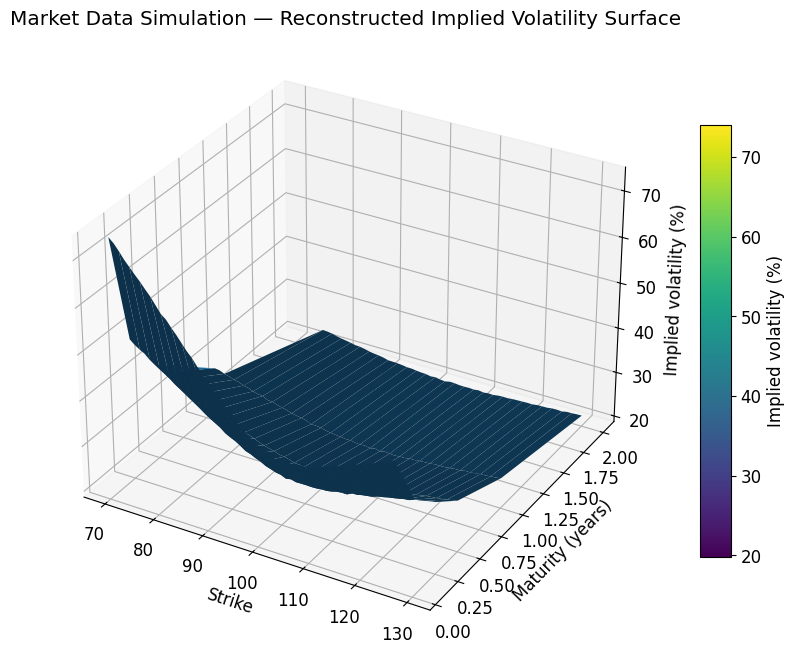

In [50]:
# =============================================================
# MARKET DATA SIMULATION — 3D reconstructed implied volatility surface
# =============================================================

strike_mesh, maturity_mesh = np.meshgrid(
    MARKET_DATA_STRIKES,
    MARKET_DATA_MATURITIES
)

reconstructed_iv_surface_percent = 100.0 * reconstructed_iv_matrix

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surface_plot = ax.plot_surface(
    strike_mesh,
    maturity_mesh,
    reconstructed_iv_surface_percent,
    linewidth=0,
    antialiased=True,
    vmin=np.nanmin(reconstructed_iv_surface_percent),
    vmax=np.nanmax(reconstructed_iv_surface_percent)
)

surface_plot.set_clim(
    np.nanmin(reconstructed_iv_surface_percent),
    np.nanmax(reconstructed_iv_surface_percent)
)

ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (years)")
ax.set_zlabel("Implied volatility (%)")
ax.set_title("Market Data Simulation — Reconstructed Implied Volatility Surface")

fig.colorbar(
    surface_plot,
    ax=ax,
    shrink=0.7,
    aspect=14,
    label="Implied volatility (%)"
)

plt.show()

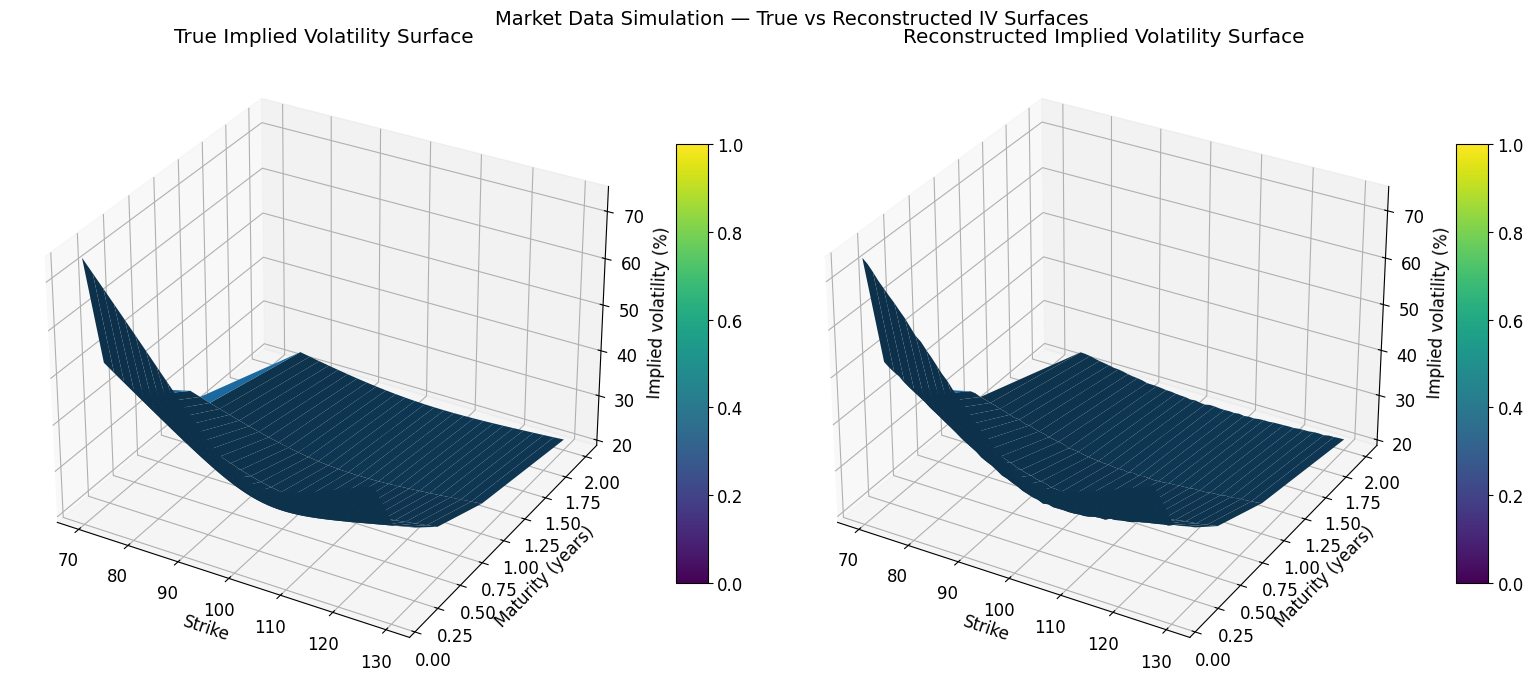

In [51]:
# =============================================================
# MARKET DATA SIMULATION — 3D comparison: true vs reconstructed surface
# =============================================================

fig = plt.figure(figsize=(16, 7))

# True surface
ax1 = fig.add_subplot(121, projection="3d")
true_surface_plot = ax1.plot_surface(
    strike_mesh,
    maturity_mesh,
    100.0 * true_iv_matrix_on_clean_grid,
    linewidth=0,
    antialiased=True
)
ax1.set_xlabel("Strike")
ax1.set_ylabel("Maturity (years)")
ax1.set_zlabel("Implied volatility (%)")
ax1.set_title("True Implied Volatility Surface")
fig.colorbar(true_surface_plot, ax=ax1, shrink=0.7, aspect=14)

# Reconstructed surface
ax2 = fig.add_subplot(122, projection="3d")
reconstructed_surface_plot = ax2.plot_surface(
    strike_mesh,
    maturity_mesh,
    100.0 * reconstructed_iv_matrix,
    linewidth=0,
    antialiased=True
)
ax2.set_xlabel("Strike")
ax2.set_ylabel("Maturity (years)")
ax2.set_zlabel("Implied volatility (%)")
ax2.set_title("Reconstructed Implied Volatility Surface")
fig.colorbar(reconstructed_surface_plot, ax=ax2, shrink=0.7, aspect=14)

plt.suptitle("Market Data Simulation — True vs Reconstructed IV Surfaces", fontsize=14)
plt.tight_layout()
plt.show()

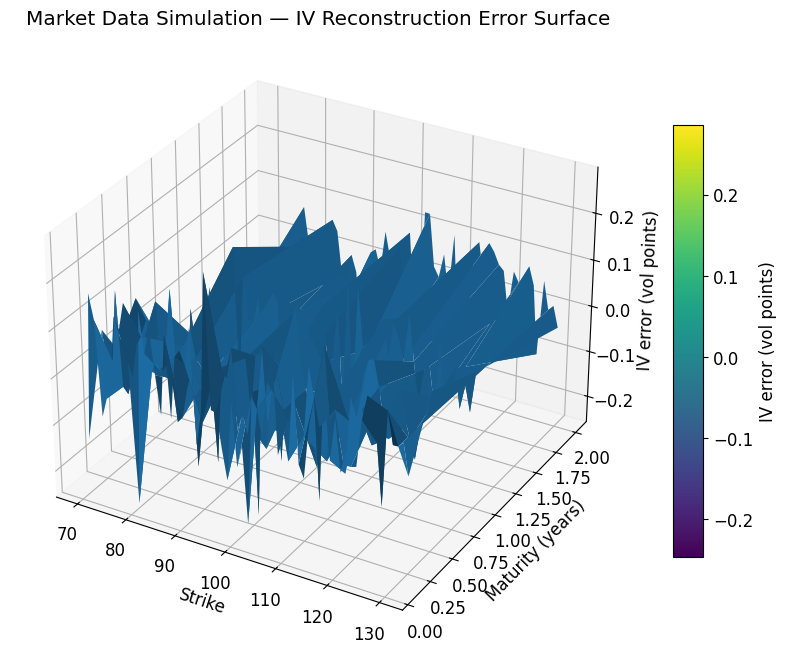

In [52]:
# =============================================================
# MARKET DATA SIMULATION — 3D reconstruction error surface
# =============================================================

iv_error_matrix = reconstructed_iv_matrix - true_iv_matrix_on_clean_grid
iv_error_surface_vol_points = 100.0 * iv_error_matrix

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

error_surface_plot = ax.plot_surface(
    strike_mesh,
    maturity_mesh,
    iv_error_surface_vol_points,
    linewidth=0,
    antialiased=True,
    vmin=np.nanmin(iv_error_surface_vol_points),
    vmax=np.nanmax(iv_error_surface_vol_points)
)

error_surface_plot.set_clim(
    np.nanmin(iv_error_surface_vol_points),
    np.nanmax(iv_error_surface_vol_points)
)

ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (years)")
ax.set_zlabel("IV error (vol points)")
ax.set_title("Market Data Simulation — IV Reconstruction Error Surface")

fig.colorbar(
    error_surface_plot,
    ax=ax,
    shrink=0.7,
    aspect=14,
    label="IV error (vol points)"
)

plt.show()

### Market Data Simulation Interpretation

This section adds a market-data-like layer before the local volatility extraction.

Starting from the synthetic SVI implied volatility surface, we generated a realistic option chain with OTM option selection, bid/ask spreads, mid-price noise and volume-based liquidity. The quote cleaning step removed low-quality quotes with excessive relative spreads or insufficient volume, while preserving most of the surface information.

The implied volatility reconstruction is stable: all cleaned quotes were successfully inverted, the mean reconstruction error is close to zero, and the mean absolute error remains small. The reconstructed 3D implied volatility surface is visually very close to the original SVI surface, while the error surface confirms that deviations remain limited and mostly reflect quote noise.

This validates the market data pipeline:
raw option-like quotes → quote cleaning → mid prices → implied volatility reconstruction → reconstructed volatility surface.

The data remains simulated, but the workflow is closer to what would be required in a real calibration setting before applying Dupire's local volatility formula.

### 3D Surface Reconstruction Interpretation

The reconstructed implied volatility surface is very close to the original SVI surface. The equity-style skew is preserved: short-maturity low strikes display the highest implied volatility, while longer maturities are smoother and flatter.

The reconstruction error surface remains small in absolute magnitude. The observed spikes are not structural model errors; they mainly reflect the simulated bid/ask noise and the inversion of noisy mid prices. The average absolute reconstruction error remains below one tenth of a volatility point, which confirms that the quote cleaning and implied volatility inversion pipeline is numerically stable.

This validates the market-data-like workflow:
synthetic option quotes → bid/ask filtering → mid prices → implied volatility inversion → reconstructed 3D volatility surface.

# Conclusion

## Ce qu'on a construit

On a implémenté un pipeline complet de pricing et de monitoring pour options exotiques sous volatilité locale.

La chaîne de calcul couvre désormais l'ensemble du workflow :

1. **Pricer Black-Scholes** — brique de base pour valoriser calls/puts vanilles et inverser les prix en volatilités implicites via Brent.

2. **Surface de volatilité implicite** — construction d'une surface SVI de type equity, interpolée en bicubique, avec un skew négatif marqué et une structure par maturité cohérente.

3. **Market-data-like simulation** — génération d'une chaîne d'options simulée avec strikes, maturités, type d'option OTM, prix théorique, bid, ask, mid, spread et volume.

4. **Quote cleaning** — filtrage des quotes selon des critères simples mais réalistes : spread relatif, volume minimal, bid/ask cohérents et respect des bornes de non-arbitrage.

5. **Implied volatility reconstruction** — reconstruction des volatilités implicites à partir des mid prices bruités. La surface reconstruite reste très proche de la surface SVI initiale, avec une erreur moyenne faible et aucune inversion ratée.

6. **Dupire local volatility** — extraction de la volatilité locale par différences finies sur la surface de prix. La vol locale amplifie le smile : elle est plus extrême que la vol implicite car cette dernière est une moyenne sur l'horizon de maturité.

7. **Monte Carlo sous volatilité locale** — simulation par schéma d'Euler-Maruyama en log-spot, avec pré-calcul de la volatilité locale sur une grille afin de rendre le pricing praticable.

8. **Pricing d'options barrières** — pricing de down-and-out calls et comparaison entre volatilité locale et Black-Scholes flat-vol. L'écart de prix dépend fortement de la position de la barrière par rapport à la structure locale de volatilité.

9. **Greeks et P&L diagnostics** — calcul du delta et du gamma par bump-and-reprice, puis comparaison entre P&L full revaluation et approximation Delta-Gamma.

10. **Risk monitoring** — ajout d'une couche de diagnostic desk-oriented : model risk, spot stress, barrier stress, probabilité de knock-out et full revaluation P&L.

## Résultat principal

Le résultat central est que deux modèles cohérents avec les mêmes prix vanilles peuvent donner des prix différents pour une option barrière.

Le modèle Black-Scholes flat-vol et le modèle de volatilité locale peuvent être calibrés de manière cohérente sur une même information de marché vanille, mais ils n'impliquent pas la même dynamique de trajectoire. Or une option barrière dépend de toute la trajectoire du sous-jacent, pas seulement de sa distribution terminale.

Ainsi, selon la position de la barrière :

- si la barrière se situe dans une zone où la volatilité locale est supérieure à la volatilité ATM, la probabilité de knock-out augmente et le down-and-out call devient moins cher sous Dupire ;
- si la barrière se situe dans une zone où la volatilité locale est inférieure à la volatilité ATM, l'effet peut s'inverser.

C'est la justification économique du modèle de Dupire pour les produits path-dependent : la surface de volatilité ne sert pas seulement à repricer les vanilles, elle modifie aussi la dynamique locale utilisée pour valoriser les exotiques.

## Apport de la couche Market Data Simulation

La nouvelle brique market data rend le projet plus proche d'un workflow réel de calibration.

Au lieu de supposer directement une surface de volatilité propre, on simule une chaîne d'options avec bid/ask, mid prices, spreads et volumes. On applique ensuite un nettoyage des quotes, puis on reconstruit les volatilités implicites à partir des prix mid.

Cette étape valide le pipeline suivant :

```text
option quotes → quote cleaning → mid prices → implied volatility inversion → reconstructed IV surface

In [53]:
# =============================================================
# EXPORT KEY FIGURES FOR GITHUB README
# =============================================================

from pathlib import Path

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved in: {FIGURES_DIR.resolve()}")

Figures will be saved in: C:\Users\PC\Desktop\CV\projet\projet vol local\local-volatility-exotic-option-pricing\figures


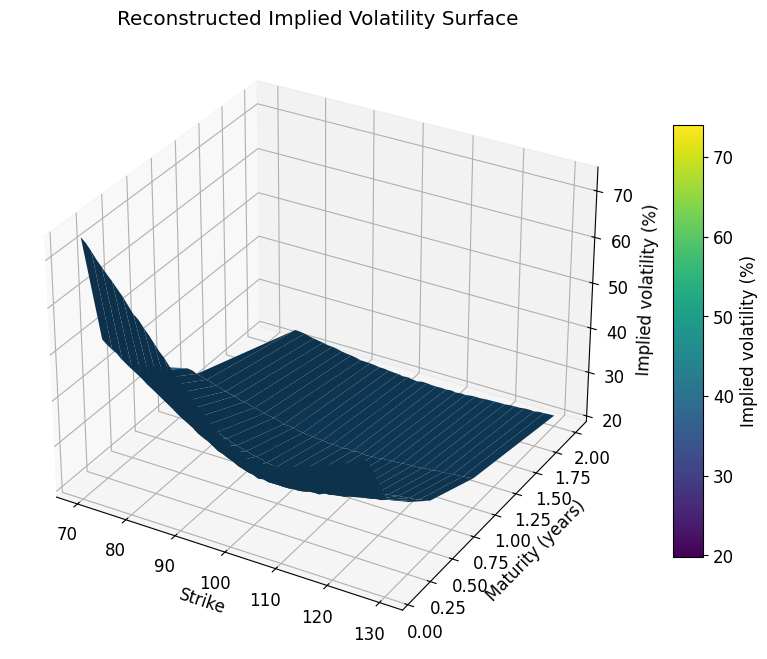

In [54]:
# =============================================================
# EXPORT — Reconstructed implied volatility surface
# =============================================================

reconstructed_iv_surface_percent = 100.0 * reconstructed_iv_matrix

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surface_plot = ax.plot_surface(
    strike_mesh,
    maturity_mesh,
    reconstructed_iv_surface_percent,
    linewidth=0,
    antialiased=True,
    vmin=np.nanmin(reconstructed_iv_surface_percent),
    vmax=np.nanmax(reconstructed_iv_surface_percent)
)

surface_plot.set_clim(
    np.nanmin(reconstructed_iv_surface_percent),
    np.nanmax(reconstructed_iv_surface_percent)
)

ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (years)")
ax.set_zlabel("Implied volatility (%)")
ax.set_title("Reconstructed Implied Volatility Surface")

fig.colorbar(
    surface_plot,
    ax=ax,
    shrink=0.7,
    aspect=14,
    label="Implied volatility (%)"
)

plt.savefig(FIGURES_DIR / "reconstructed_iv_surface.png", dpi=160, bbox_inches="tight")
plt.show()

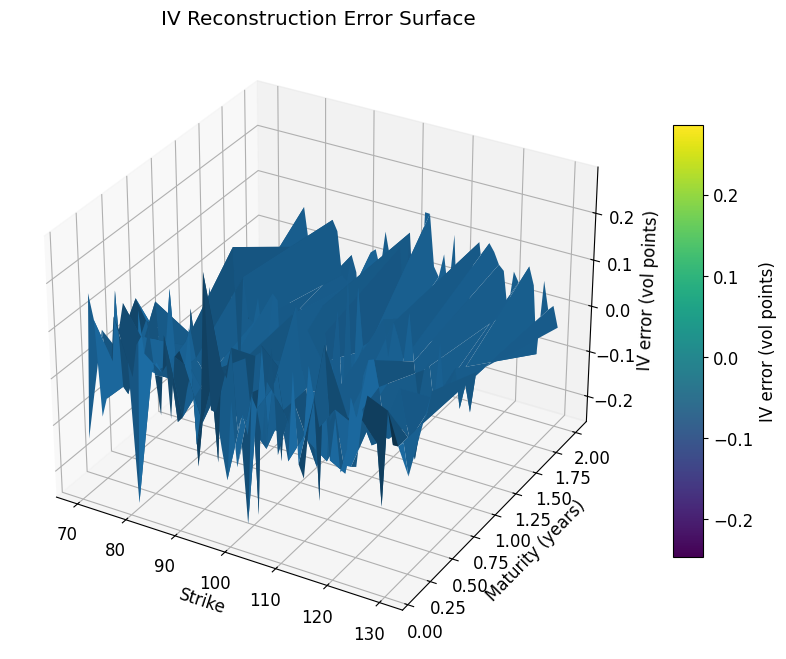

In [55]:
# =============================================================
# EXPORT — IV reconstruction error surface
# =============================================================

iv_error_matrix = reconstructed_iv_matrix - true_iv_matrix_on_clean_grid
iv_error_surface_vol_points = 100.0 * iv_error_matrix

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

error_surface_plot = ax.plot_surface(
    strike_mesh,
    maturity_mesh,
    iv_error_surface_vol_points,
    linewidth=0,
    antialiased=True,
    vmin=np.nanmin(iv_error_surface_vol_points),
    vmax=np.nanmax(iv_error_surface_vol_points)
)

error_surface_plot.set_clim(
    np.nanmin(iv_error_surface_vol_points),
    np.nanmax(iv_error_surface_vol_points)
)

ax.set_xlabel("Strike")
ax.set_ylabel("Maturity (years)")
ax.set_zlabel("IV error (vol points)")
ax.set_title("IV Reconstruction Error Surface")

fig.colorbar(
    error_surface_plot,
    ax=ax,
    shrink=0.7,
    aspect=14,
    label="IV error (vol points)"
)

plt.savefig(FIGURES_DIR / "iv_reconstruction_error_surface.png", dpi=160, bbox_inches="tight")
plt.show()

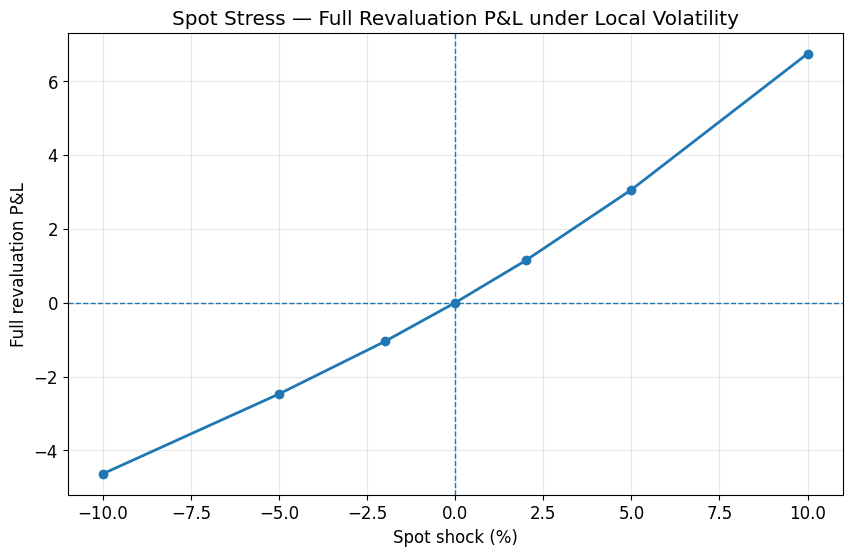

In [56]:
# =============================================================
# EXPORT — Spot stress full revaluation P&L
# =============================================================

spot_shocks_percent = np.array([
    100.0 * row["spot_shock"]
    for row in spot_stress_results
])

spot_stress_pnl = np.array([
    row["full_revaluation_pnl"]
    for row in spot_stress_results
])

plt.figure(figsize=(10, 6))
plt.plot(spot_shocks_percent, spot_stress_pnl, marker="o", linewidth=2)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot shock (%)")
plt.ylabel("Full revaluation P&L")
plt.title("Spot Stress — Full Revaluation P&L under Local Volatility")
plt.grid(True)

plt.savefig(FIGURES_DIR / "spot_stress_pnl.png", dpi=160, bbox_inches="tight")
plt.show()

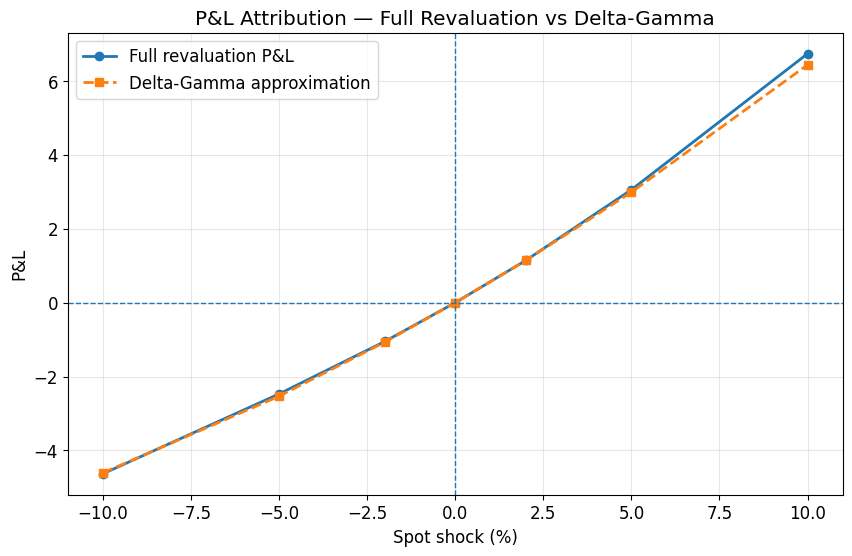

In [57]:
# =============================================================
# EXPORT — Delta-Gamma P&L attribution
# =============================================================

pnl_attribution_shocks_percent = np.array([
    100.0 * row["spot_shock"]
    for row in pnl_attribution_results
])

full_revaluation_pnl_values = np.array([
    row["full_revaluation_pnl"]
    for row in pnl_attribution_results
])

delta_gamma_pnl_values = np.array([
    row["delta_gamma_pnl"]
    for row in pnl_attribution_results
])

plt.figure(figsize=(10, 6))
plt.plot(
    pnl_attribution_shocks_percent,
    full_revaluation_pnl_values,
    marker="o",
    linewidth=2,
    label="Full revaluation P&L"
)
plt.plot(
    pnl_attribution_shocks_percent,
    delta_gamma_pnl_values,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Delta-Gamma approximation"
)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Spot shock (%)")
plt.ylabel("P&L")
plt.title("P&L Attribution — Full Revaluation vs Delta-Gamma")
plt.legend()
plt.grid(True)

plt.savefig(FIGURES_DIR / "delta_gamma_pnl_attribution.png", dpi=160, bbox_inches="tight")
plt.show()

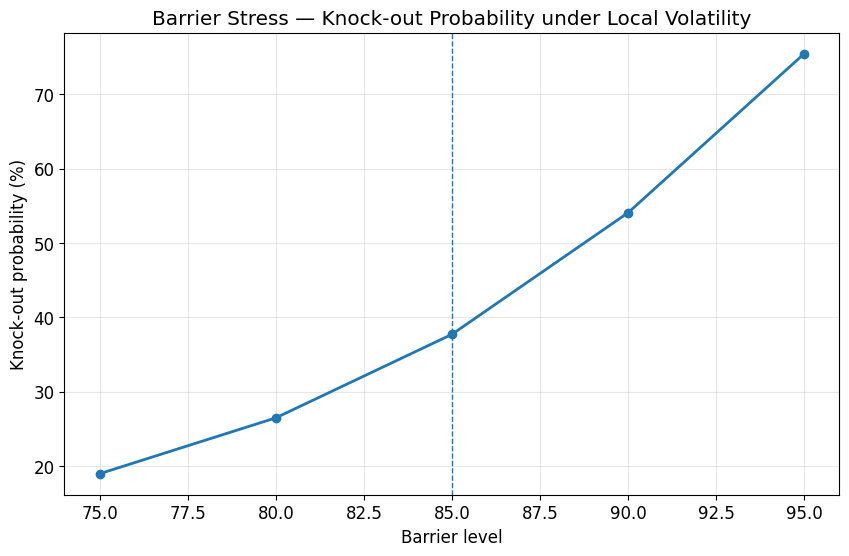

In [58]:
# =============================================================
# EXPORT — Barrier stress knock-out probability
# =============================================================

barrier_levels = np.array([
    row["barrier"]
    for row in barrier_stress_results
])

barrier_knock_out_probabilities = np.array([
    row["knock_out_probability"]
    for row in barrier_stress_results
])

plt.figure(figsize=(10, 6))
plt.plot(
    barrier_levels,
    100.0 * barrier_knock_out_probabilities,
    marker="o",
    linewidth=2
)
plt.axvline(RISK_BARRIER, linestyle="--", linewidth=1)
plt.xlabel("Barrier level")
plt.ylabel("Knock-out probability (%)")
plt.title("Barrier Stress — Knock-out Probability under Local Volatility")
plt.grid(True)

plt.savefig(FIGURES_DIR / "barrier_stress_knockout_probability.png", dpi=160, bbox_inches="tight")
plt.show()